<a href="https://colab.research.google.com/github/manushi0304/CapstoneProject/blob/main/MobilneNETV2FInal.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Colab cell 1: Runtime setup
# (Run this cell first)
# If you're not in Colab you can still run; make sure PyTorch + torchvision are installed.
!nvidia-smi || true

Wed Apr  8 13:29:29 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   33C    P8              9W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [ ]:
# Colab cell 2: Install optional helper packages
# thop for FLOPs counting. If already installed, pip will be fast.
!pip install -q thop
!pip install -q onnx
!pip install -q onnxscript

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17.6/17.6 MB 56.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 689.1/689.1 kB 16.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 164.1/164.1 kB 20.8 MB/s eta 0:00:00


In [ ]:
"""
Cell 1: Configuration and Setup
================================
Centralized configuration for the NAS+Pruning pipeline.
"""

import os
import random
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader, SubsetRandomSampler
import torchvision
from torchvision import transforms, datasets, models
import torch.nn.utils.prune as prune
from thop import profile
import matplotlib.pyplot as plt
import time
import copy
from typing import Dict, List, Tuple, Optional
import warnings
warnings.filterwarnings('ignore')

# ============================================================================
# CONFIGURATION CLASS
# ============================================================================

class Config:
    """Centralized configuration for reproducibility and easy tuning."""

    # Hardware
    DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    NUM_WORKERS = 2
    PIN_MEMORY = True

    # Reproducibility
    SEED = 42

    # Data
    DATA_DIR = './data'
    BATCH_SIZE = 128
    NUM_CLASSES = 10
    VALIDATION_SPLIT = 0.2  # 20% of training data for validation

    # Training - Baseline
    BASELINE_EPOCHS = 50
    BASELINE_LR = 0.1
    BASELINE_MOMENTUM = 0.9
    BASELINE_WEIGHT_DECAY = 5e-4
    BASELINE_MILESTONES = [25,40]  # LR decay at these epochs
    BASELINE_GAMMA = 0.1

    # Training - Fine-tuning after pruning
    FINETUNE_EPOCHS = 30
    FINETUNE_LR = 0.01
    FINETUNE_MOMENTUM = 0.9
    FINETUNE_WEIGHT_DECAY = 5e-4
    FINETUNE_STEP_SIZE = 15
    FINETUNE_GAMMA = 0.5

    # Pruning
    PRUNE_AMOUNT = 0.3  # 30% of filters to prune
    PRUNE_SKIP_DEPTHWISE = True  # Skip depthwise convolutions
    PRUNE_SKIP_FIRST_LAST = True  # Skip first and last layers

    # DARTS Search
    DARTS_INIT_CHANNELS = 16
    DARTS_LAYERS = 6
    DARTS_SEARCH_EPOCHS = 50
    DARTS_SEARCH_BATCHES_PER_EPOCH = 50  # Limit batches per epoch for speed
    DARTS_WEIGHT_LR = 0.025
    DARTS_WEIGHT_MOMENTUM = 0.9
    DARTS_WEIGHT_DECAY = 3e-4
    DARTS_ARCH_LR = 3e-4
    DARTS_ARCH_WEIGHT_DECAY = 1e-3

    # DARTS Final Training
    DARTS_TRAIN_EPOCHS = 50
    DARTS_TRAIN_LR = 0.025
    DARTS_TRAIN_MOMENTUM = 0.9
    DARTS_TRAIN_WEIGHT_DECAY = 3e-4
    DARTS_TRAIN_MILESTONES = [25, 40]
    DARTS_TRAIN_GAMMA = 0.1

    # DARTS + Pruning Combined
    DARTS_PRUNE_AMOUNT = 0.3
    DARTS_FINETUNE_EPOCHS = 30
    DARTS_FINETUNE_LR = 0.01
    DARTS_FINETUNE_WEIGHT_DECAY = 1e-4

    # Evaluation
    INFERENCE_WARMUP_BATCHES = 3
    INFERENCE_MEASURE_BATCHES = 20

    # Paths
    MODEL_DIR = './models'
    RESULTS_DIR = './results'

    @classmethod
    def print_config(cls):
        """Print all configuration parameters."""
        print("=" * 70)
        print("CONFIGURATION")
        print("=" * 70)
        for attr in dir(cls):
            if not attr.startswith('_') and attr.isupper():
                print(f"{attr:30s}: {getattr(cls, attr)}")
        print("=" * 70)


# ============================================================================
# REPRODUCIBILITY SETUP
# ============================================================================

def set_seed(seed: int = 42):
    """Set random seeds for reproducibility."""
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    print(f"✅ Random seed set to {seed}")


# ============================================================================
# DIRECTORY SETUP
# ============================================================================

def setup_directories():
    """Create necessary directories."""
    os.makedirs(Config.MODEL_DIR, exist_ok=True)
    os.makedirs(Config.RESULTS_DIR, exist_ok=True)
    print(f"✅ Directories created: {Config.MODEL_DIR}, {Config.RESULTS_DIR}")


# ============================================================================
# INITIALIZE
# ============================================================================

if __name__ == "__main__":
    Config.print_config()
    set_seed(Config.SEED)
    setup_directories()
    print(f"✅ Using device: {Config.DEVICE}")

CONFIGURATION
BASELINE_EPOCHS               : 50
BASELINE_GAMMA                : 0.1
BASELINE_LR                   : 0.1
BASELINE_MILESTONES           : [25, 40]
BASELINE_MOMENTUM             : 0.9
BASELINE_WEIGHT_DECAY         : 0.0005
BATCH_SIZE                    : 128
DARTS_ARCH_LR                 : 0.0003
DARTS_ARCH_WEIGHT_DECAY       : 0.001
DARTS_FINETUNE_EPOCHS         : 30
DARTS_FINETUNE_LR             : 0.01
DARTS_FINETUNE_WEIGHT_DECAY   : 0.0001
DARTS_INIT_CHANNELS           : 16
DARTS_LAYERS                  : 6
DARTS_PRUNE_AMOUNT            : 0.3
DARTS_SEARCH_BATCHES_PER_EPOCH: 50
DARTS_SEARCH_EPOCHS           : 50
DARTS_TRAIN_EPOCHS            : 50
DARTS_TRAIN_GAMMA             : 0.1
DARTS_TRAIN_LR                : 0.025
DARTS_TRAIN_MILESTONES        : [25, 40]
DARTS_TRAIN_MOMENTUM          : 0.9
DARTS_TRAIN_WEIGHT_DECAY      : 0.0003
DARTS_WEIGHT_DECAY            : 0.0003
DARTS_WEIGHT_LR               : 0.025
DARTS_WEIGHT_MOMENTUM         : 0.9
DATA_DIR                  

In [ ]:
#2
from typing import Tuple
from torch.utils.data import DataLoader, SubsetRandomSampler
from torchvision import transforms, datasets
import numpy as np


# ============================================================================
# DATA TRANSFORMS
# ============================================================================

def get_transforms() -> Tuple[transforms.Compose, transforms.Compose]:
    """
    Get data augmentation transforms for CIFAR-10.

    Returns:
        train_transform: Augmentation for training
        test_transform: Normalization only for testing
    """
    # CIFAR-10 normalization constants
    CIFAR_MEAN = (0.4914, 0.4822, 0.4465)
    CIFAR_STD = (0.2023, 0.1994, 0.2010)

    train_transform = transforms.Compose([
        transforms.RandomCrop(32, padding=4),
        transforms.RandomHorizontalFlip(),
        transforms.ToTensor(),
        transforms.Normalize(CIFAR_MEAN, CIFAR_STD)
    ])

    test_transform = transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize(CIFAR_MEAN, CIFAR_STD)
    ])

    return train_transform, test_transform


# ============================================================================
# DATASET LOADING
# ============================================================================

def load_cifar10(config) -> Tuple:
    """
    Load CIFAR-10 with proper train/validation split.

    Args:
        config: Configuration object

    Returns:
        trainloader: Training data loader
        validloader: Validation data loader (from training set)
        testloader: Test data loader
        train_dataset: Full training dataset
        test_dataset: Test dataset
    """
    train_transform, test_transform = get_transforms()

    # Load datasets
    train_dataset = datasets.CIFAR10(
        root=config.DATA_DIR,
        train=True,
        download=True,
        transform=train_transform
    )

    test_dataset = datasets.CIFAR10(
        root=config.DATA_DIR,
        train=False,
        download=True,
        transform=test_transform
    )

    # Create train/validation split for DARTS
    num_train = len(train_dataset)
    indices = list(range(num_train))
    split = int(np.floor(config.VALIDATION_SPLIT * num_train))

    # Shuffle indices
    np.random.seed(config.SEED)
    np.random.shuffle(indices)

    train_idx, valid_idx = indices[split:], indices[:split]

    # Create samplers
    train_sampler = SubsetRandomSampler(train_idx)
    valid_sampler = SubsetRandomSampler(valid_idx)

    # Create data loaders
    trainloader = DataLoader(
        train_dataset,
        batch_size=config.BATCH_SIZE,
        sampler=train_sampler,
        num_workers=config.NUM_WORKERS,
        pin_memory=config.PIN_MEMORY
    )

    validloader = DataLoader(
        train_dataset,
        batch_size=config.BATCH_SIZE,
        sampler=valid_sampler,
        num_workers=config.NUM_WORKERS,
        pin_memory=config.PIN_MEMORY
    )

    testloader = DataLoader(
        test_dataset,
        batch_size=config.BATCH_SIZE,
        shuffle=False,
        num_workers=config.NUM_WORKERS,
        pin_memory=config.PIN_MEMORY
    )

    print(f"✅ CIFAR-10 loaded:")
    print(f"   Training samples: {len(train_idx)}")
    print(f"   Validation samples: {len(valid_idx)}")
    print(f"   Test samples: {len(test_dataset)}")

    return trainloader, validloader, testloader, train_dataset, test_dataset


# ============================================================================
# UTILITY: FULL TRAINING LOADER (NO VALIDATION SPLIT)
# ============================================================================

def get_full_trainloader(train_dataset, config) -> DataLoader:
    """
    Get a data loader for the full training set (for final training).

    Args:
        train_dataset: Training dataset
        config: Configuration object

    Returns:
        DataLoader for full training set
    """
    return DataLoader(
        train_dataset,
        batch_size=config.BATCH_SIZE,
        shuffle=True,
        num_workers=config.NUM_WORKERS,
        pin_memory=config.PIN_MEMORY
    )


# ============================================================================
# MAIN EXECUTION
# ============================================================================

if __name__ == "__main__":
    # Removed: from cell_01_config_setup import Config, set_seed
    # Config and set_seed are already available in the global scope
    # from previous cell execution.

    set_seed(Config.SEED)
    trainloader, validloader, testloader, train_dataset, test_dataset = load_cifar10(Config)

    # Verify data loading
    images, labels = next(iter(trainloader))
    print(f"✅ Batch shape: {images.shape}, Labels: {labels.shape}")
    print(f"✅ Image range: [{images.min():.2f}, {images.max():.2f}]")

✅ Random seed set to 42


100%|██████████| 170M/170M [05:53<00:00, 482kB/s]


✅ CIFAR-10 loaded:
   Training samples: 40000
   Validation samples: 10000
   Test samples: 10000
✅ Batch shape: torch.Size([128, 3, 32, 32]), Labels: torch.Size([128])
✅ Image range: [-2.43, 2.75]


In [ ]:
"""
Cell 3: Utility Functions
==========================
Training, evaluation, and metric computation utilities.
"""

import time
import torch
import torch.nn as nn
import torch.nn.functional as F
from thop import profile
import copy
from typing import Tuple, Optional


# ============================================================================
# EVALUATION
# ============================================================================

def evaluate(
    model: nn.Module,
    loader: torch.utils.data.DataLoader,
    device: torch.device,
    criterion: Optional[nn.Module] = None
) -> Tuple[float, float]:
    """
    Evaluate model on a dataset.

    Args:
        model: PyTorch model
        loader: Data loader
        device: Device to run on
        criterion: Loss function (defaults to CrossEntropyLoss)

    Returns:
        avg_loss: Average loss
        accuracy: Accuracy percentage
    """
    if criterion is None:
        criterion = nn.CrossEntropyLoss()

    model.eval()
    total_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            total_loss += loss.item() * images.size(0)
            _, predicted = outputs.max(1)
            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()

    avg_loss = total_loss / total
    accuracy = 100.0 * correct / total

    return avg_loss, accuracy


# ============================================================================
# TRAINING
# ============================================================================

def train_epoch(
    model: nn.Module,
    loader: torch.utils.data.DataLoader,
    optimizer: torch.optim.Optimizer,
    device: torch.device,
    criterion: Optional[nn.Module] = None,
    max_batches: Optional[int] = None
) -> Tuple[float, float]:
    """
    Train model for one epoch.

    Args:
        model: PyTorch model
        loader: Data loader
        optimizer: Optimizer
        device: Device to run on
        criterion: Loss function
        max_batches: Maximum number of batches (for limiting in DARTS search)

    Returns:
        avg_loss: Average training loss
        accuracy: Training accuracy percentage
    """
    if criterion is None:
        criterion = nn.CrossEntropyLoss()

    model.train()
    total_loss = 0.0
    correct = 0
    total = 0

    for batch_idx, (images, labels) in enumerate(loader):
        if max_batches is not None and batch_idx >= max_batches:
            break

        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * images.size(0)
        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()

    avg_loss = total_loss / total if total > 0 else 0.0
    accuracy = 100.0 * correct / total if total > 0 else 0.0

    return avg_loss, accuracy


def train_model(
    model: nn.Module,
    trainloader: torch.utils.data.DataLoader,
    testloader: torch.utils.data.DataLoader,
    config,
    epochs: int,
    lr: float,
    save_path: Optional[str] = None,
    verbose: bool = True
) -> nn.Module:
    """
    Complete training loop with evaluation and checkpointing.

    Args:
        model: PyTorch model
        trainloader: Training data loader
        testloader: Test data loader
        config: Configuration object
        epochs: Number of epochs
        lr: Learning rate
        save_path: Path to save best model
        verbose: Print progress

    Returns:
        Trained model
    """
    device = config.DEVICE
    model = model.to(device)

    optimizer = torch.optim.SGD(
        model.parameters(),
        lr=lr,
        momentum=config.BASELINE_MOMENTUM,
        weight_decay=config.BASELINE_WEIGHT_DECAY
    )

    scheduler = torch.optim.lr_scheduler.MultiStepLR(
        optimizer,
        milestones=config.BASELINE_MILESTONES,
        gamma=config.BASELINE_GAMMA
    )

    criterion = nn.CrossEntropyLoss()
    best_acc = 0.0
    best_model_state = None

    for epoch in range(1, epochs + 1):
        # Train
        train_loss, train_acc = train_epoch(model, trainloader, optimizer, device, criterion)

        # Evaluate
        val_loss, val_acc = evaluate(model, testloader, device, criterion)

        # Update learning rate
        scheduler.step()

        if verbose:
            print(f"Epoch {epoch:3d}/{epochs} | "
                  f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.2f}% | "
                  f"Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.2f}%")

        # Save best model
        if val_acc > best_acc:
            best_acc = val_acc
            best_model_state = copy.deepcopy(model.state_dict())
            if save_path:
                torch.save(best_model_state, save_path)
                if verbose:
                    print(f"   ✅ Best model saved (acc: {best_acc:.2f}%) Kishan")

    # Load best model
    if best_model_state is not None:
        model.load_state_dict(best_model_state)

    return model


# ============================================================================
# METRICS
# ============================================================================

def count_parameters(model: nn.Module) -> Tuple[int, int]:
    """
    Count total and non-zero parameters.

    Args:
        model: PyTorch model

    Returns:
        total_params: Total number of parameters
        nonzero_params: Number of non-zero parameters
    """
    total = sum(p.numel() for p in model.parameters())
    nonzero = sum(torch.count_nonzero(p).item() for p in model.parameters())
    return total, nonzero


def measure_flops(
    model: nn.Module,
    input_size: Tuple[int, ...] = (1, 3, 32, 32)
) -> Tuple[int, int]:
    """
    Measure FLOPs and parameters using thop.

    Args:
        model: PyTorch model
        input_size: Input tensor size

    Returns:
        macs: Multiply-accumulate operations
        params: Number of parameters
    """
    model_cpu = copy.deepcopy(model).cpu()
    model_cpu.eval()

    dummy_input = torch.randn(input_size)

    try:
        macs, params = profile(model_cpu, inputs=(dummy_input,), verbose=False)
        return int(macs), int(params)
    except Exception as e:
        print(f"⚠️  FLOPs measurement failed: {e}")
        return 0, 0


def measure_inference_time(
    model: nn.Module,
    loader: torch.utils.data.DataLoader,
    device: torch.device,
    warmup_batches: int = 3,
    measure_batches: int = 20
) -> float:
    """
    Measure average per-image inference time.

    Args:
        model: PyTorch model
        loader: Data loader
        device: Device to run on
        warmup_batches: Number of warmup iterations
        measure_batches: Number of batches to measure

    Returns:
        Per-image inference time in seconds
    """
    model.eval()

    # Warmup
    with torch.no_grad():
        for i, (images, _) in enumerate(loader):
            if i >= warmup_batches:
                break
            images = images.to(device)
            _ = model(images)

    # Measure
    timings = []
    with torch.no_grad():
        for i, (images, _) in enumerate(loader):
            if i >= measure_batches:
                break
            images = images.to(device)

            # Synchronize GPU
            if device.type == 'cuda':
                torch.cuda.synchronize()

            start = time.time()
            _ = model(images)

            if device.type == 'cuda':
                torch.cuda.synchronize()

            end = time.time()
            timings.append(end - start)

    if len(timings) == 0:
        return float('nan')

    avg_batch_time = sum(timings) / len(timings)
    per_image_time = avg_batch_time / loader.batch_size

    return per_image_time


def collect_metrics(
    model: nn.Module,
    testloader: torch.utils.data.DataLoader,
    config,
    label: str,
    baseline_inf_time_ms: Optional[float] = None
) -> dict:
    """
    Collect all metrics for a model.

    Args:
        model: PyTorch model
        testloader: Test data loader
        config: Configuration object
        label: Model label for identification
        baseline_inf_time_ms: Baseline inference time (ms/image) for computing
                              latency reduction and speed-up relative to baseline

    Returns:
        Dictionary with all metrics including throughput, speed, and latency reduction
    """
    device = config.DEVICE
    model = model.to(device)

    # Evaluate
    val_loss, val_acc = evaluate(model, testloader, device)

    # Count parameters
    total_params, nonzero_params = count_parameters(model)

    # Measure FLOPs
    macs, params_thop = measure_flops(model)

    # Measure inference time (per-image latency in seconds)
    inf_time_sec = measure_inference_time(
        model, testloader, device,
        warmup_batches=config.INFERENCE_WARMUP_BATCHES,
        measure_batches=config.INFERENCE_MEASURE_BATCHES
    )
    inf_time_ms = inf_time_sec * 1000  # ms / image

    # Throughput: images per second
    throughput = 1.0 / inf_time_sec if inf_time_sec > 0 else float('nan')

    # Speed-up and latency reduction vs baseline
    if baseline_inf_time_ms is not None and baseline_inf_time_ms > 0:
        speedup = baseline_inf_time_ms / inf_time_ms  # >1 means faster
        latency_reduction_pct = (1.0 - inf_time_ms / baseline_inf_time_ms) * 100.0
    else:
        speedup = 1.0  # self is the baseline
        latency_reduction_pct = 0.0

    return {
        'label': label,
        'val_loss': val_loss,
        'val_acc': val_acc,
        'total_params': total_params,
        'nonzero_params': nonzero_params,
        'macs': macs,
        'params_thop': params_thop,
        'inf_time_ms': inf_time_ms,
        'throughput_imgs_sec': throughput,
        'speedup': speedup,
        'latency_reduction_pct': latency_reduction_pct,
    }


def print_metrics(metrics: dict):
    """Pretty print metrics dictionary."""
    print(f"\n{'='*70}")
    print(f"Metrics for: {metrics['label']}")
    print(f"{'='*70}")
    print(f"Validation Loss:        {metrics['val_loss']:.4f}")
    print(f"Validation Accuracy:    {metrics['val_acc']:.2f}%")
    print(f"Total Parameters:       {metrics['total_params']:,}")
    print(f"Nonzero Parameters:     {metrics['nonzero_params']:,}")
    print(f"MACs:                   {metrics['macs']:,}")
    print(f"Inference Latency:      {metrics['inf_time_ms']:.2f} ms/image")
    print(f"Throughput:             {metrics.get('throughput_imgs_sec', float('nan')):.1f} images/sec")
    print(f"Speed-up vs Baseline:   {metrics.get('speedup', 1.0):.2f}x")
    print(f"Latency Reduction:      {metrics.get('latency_reduction_pct', 0.0):.1f}%")
    print(f"{'='*70}\n")


# ============================================================================
# MAIN EXECUTION (TEST)
# ============================================================================

if __name__ == "__main__":
    # from cell_01_config_setup import Config, set_seed  # Removed this line
    # from cell_02_data_loading import load_cifar10 # Removed this line

    set_seed(Config.SEED)
    _, _, testloader, _, _ = load_cifar10(Config)

    # Test with a simple model
    model = torch.nn.Sequential(
        torch.nn.Conv2d(3, 16, 3, padding=1),
        torch.nn.ReLU(),
        torch.nn.AdaptiveAvgPool2d(1),
        torch.nn.Flatten(),
        torch.nn.Linear(16, 10)
    )

    metrics = collect_metrics(model, testloader, Config, "Test Model")
    print_metrics(metrics)

✅ Random seed set to 42
✅ CIFAR-10 loaded:
   Training samples: 40000
   Validation samples: 10000
   Test samples: 10000

Metrics for: Test Model
Validation Loss:        2.3649
Validation Accuracy:    11.28%
Total Parameters:       618
Nonzero Parameters:     618
MACs:                   458,928
Inference Latency:      0.01 ms/image
Throughput:             141320.9 images/sec
Speed-up vs Baseline:   1.00x
Latency Reduction:      0.0%



In [ ]:
"""
Cell 4: Baseline Model - MobileNetV2
=====================================
Train baseline MobileNetV2 on CIFAR-10.
"""

import torch
import torch.nn as nn
from torchvision import models
import os


# ============================================================================
# MODEL DEFINITION
# ============================================================================

def get_mobilenet_v2(num_classes: int = 10, pretrained: bool = True) -> nn.Module:
    """
    Get MobileNetV2 adapted for CIFAR-10.

    Args:
        num_classes: Number of output classes
        pretrained: Use ImageNet pretrained weights

    Returns:
        MobileNetV2 model
    """
    model = models.mobilenet_v2(pretrained=pretrained)

    # Adapt classifier for CIFAR-10
    in_features = model.classifier[1].in_features
    model.classifier[1] = nn.Linear(in_features, num_classes)

    return model


# ============================================================================
# TRAINING
# ============================================================================

def train_baseline(config, trainloader, testloader, save_path: str = None):
    """
    Train baseline MobileNetV2 model.

    Args:
        config: Configuration object
        trainloader: Training data loader
        testloader: Test data loader
        save_path: Path to save trained model

    Returns:
        Trained model
    """
    print("\n" + "="*70)
    print("TRAINING BASELINE MODEL (MobileNetV2)")
    print("="*70)

    # Create model
    model = get_mobilenet_v2(
        num_classes=config.NUM_CLASSES,
        pretrained=True
    )
    model = model.to(config.DEVICE)

    # Setup optimizer and scheduler
    optimizer = torch.optim.SGD(
        model.parameters(),
        lr=config.BASELINE_LR,
        momentum=config.BASELINE_MOMENTUM,
        weight_decay=config.BASELINE_WEIGHT_DECAY
    )

    scheduler = torch.optim.lr_scheduler.MultiStepLR(
        optimizer,
        milestones=config.BASELINE_MILESTONES,
        gamma=config.BASELINE_GAMMA
    )

    criterion = nn.CrossEntropyLoss()

    # Training loop
    best_acc = 0.0
    best_model_state = None

    for epoch in range(1, config.BASELINE_EPOCHS + 1):
        # Train
        model.train()
        train_loss = 0.0
        train_correct = 0
        train_total = 0

        for images, labels in trainloader:
            images, labels = images.to(config.DEVICE), labels.to(config.DEVICE)

            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            train_loss += loss.item() * images.size(0)
            _, predicted = outputs.max(1)
            train_total += labels.size(0)
            train_correct += predicted.eq(labels).sum().item()

        train_loss = train_loss / train_total
        train_acc = 100.0 * train_correct / train_total

        # Evaluate
        model.eval()
        val_loss = 0.0
        val_correct = 0
        val_total = 0

        with torch.no_grad():
            for images, labels in testloader:
                images, labels = images.to(config.DEVICE), labels.to(config.DEVICE)
                outputs = model(images)
                loss = criterion(outputs, labels)

                val_loss += loss.item() * images.size(0)
                _, predicted = outputs.max(1)
                val_total += labels.size(0)
                val_correct += predicted.eq(labels).sum().item()

        val_loss = val_loss / val_total
        val_acc = 100.0 * val_correct / val_total

        # Update scheduler
        scheduler.step()

        # Print progress
        print(f"Epoch {epoch:3d}/{config.BASELINE_EPOCHS} | "
              f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.2f}% | "
              f"Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.2f}%")

        # Save best model
        if val_acc > best_acc:
            best_acc = val_acc
            best_model_state = model.state_dict().copy()
            if save_path:
                torch.save(best_model_state, save_path)
                print(f"   ✅ Best model saved (acc: {best_acc:.2f}%) Kishan")

    # Load best model
    if best_model_state is not None:
        model.load_state_dict(best_model_state)

    print(f"\n✅ Baseline training complete. Best accuracy: {best_acc:.2f}%")

    return model


# ============================================================================
# MAIN EXECUTION
# ============================================================================

if __name__ == "__main__":
    # from cell_01_config_setup import Config, set_seed, setup_directories
    # from cell_02_data_loading import load_cifar10, get_full_trainloader
    # from cell_03_utilities import collect_metrics, print_metrics

    # Setup
    set_seed(Config.SEED)
    setup_directories()

    # Load data (use full training set for baseline)
    _, _, testloader, train_dataset, _ = load_cifar10(Config)
    trainloader = get_full_trainloader(train_dataset, Config)

    # Train baseline
    save_path = os.path.join(Config.MODEL_DIR, 'baseline_mobilenetv2.pth')
    baseline_model = train_baseline(Config, trainloader, testloader, save_path)

    # Collect and print metrics
    metrics = collect_metrics(baseline_model, testloader, Config, "Baseline MobileNetV2")
    print_metrics(metrics)

✅ Random seed set to 42
✅ Directories created: ./models, ./results
✅ CIFAR-10 loaded:
   Training samples: 40000
   Validation samples: 10000
   Test samples: 10000

TRAINING BASELINE MODEL (MobileNetV2)
Downloading: "https://download.pytorch.org/models/mobilenet_v2-b0353104.pth" to /root/.cache/torch/hub/checkpoints/mobilenet_v2-b0353104.pth


100%|██████████| 13.6M/13.6M [00:00<00:00, 66.6MB/s]


Epoch   1/50 | Train Loss: 2.9146 | Train Acc: 10.33% | Val Loss: 2.3053 | Val Acc: 8.51%
   ✅ Best model saved (acc: 8.51%) Kishan
Epoch   2/50 | Train Loss: 2.3847 | Train Acc: 14.03% | Val Loss: 2.4056 | Val Acc: 13.34%
   ✅ Best model saved (acc: 13.34%) Kishan
Epoch   3/50 | Train Loss: 2.1914 | Train Acc: 18.13% | Val Loss: 2.4280 | Val Acc: 12.45%
Epoch   4/50 | Train Loss: 2.0896 | Train Acc: 21.53% | Val Loss: 2.3650 | Val Acc: 15.66%
   ✅ Best model saved (acc: 15.66%) Kishan
Epoch   5/50 | Train Loss: 2.0303 | Train Acc: 24.15% | Val Loss: 2.1486 | Val Acc: 19.37%
   ✅ Best model saved (acc: 19.37%) Kishan
Epoch   6/50 | Train Loss: 1.9895 | Train Acc: 26.38% | Val Loss: 2.0474 | Val Acc: 24.02%
   ✅ Best model saved (acc: 24.02%) Kishan
Epoch   7/50 | Train Loss: 1.9406 | Train Acc: 28.24% | Val Loss: 2.0057 | Val Acc: 26.33%
   ✅ Best model saved (acc: 26.33%) Kishan
Epoch   8/50 | Train Loss: 1.8959 | Train Acc: 29.91% | Val Loss: 1.9491 | Val Acc: 28.27%
   ✅ Best model 

In [ ]:
"""
Cell 5: Structured Pruning
=======================================
Simple conservative approach that WORKS.
"""

import torch
import torch.nn as nn
import numpy as np
import copy
from typing import Dict, Tuple
from torchvision.models.mobilenetv2 import InvertedResidual


def validate_model_shapes(model: nn.Module, input_size=(1, 3, 32, 32)) -> bool:
    """Validate model."""
    try:
        model.eval()
        device = next(model.parameters()).device
        dummy_input = torch.randn(input_size).to(device)

        with torch.no_grad():
            output = model(dummy_input)

        print("✅ Model shape validation passed")
        return True
    except Exception as e:
        print(f"❌ Model shape validation failed: {e}")
        return False


def extract_pruning_masks(model, prune_amount=0.3, skip_depthwise=True, skip_first_last=True):
    """Extract pruning masks."""
    masks = {}
    layer_names = [name for name, m in model.named_modules() if isinstance(m, nn.Conv2d)]

    if not layer_names:
        return masks

    first_layer, last_layer = layer_names[0], layer_names[-1]

    for name, module in model.named_modules():
        if not isinstance(module, nn.Conv2d):
            continue
        # SPECIAL CASE: Allow pruning features.0.0 (stem) for MobileNetV2
        # Only skip the very last layer (classifier)
        if skip_first_last and name == last_layer:
            print(f"   Skipping {name} (last layer)")
            continue
        if skip_depthwise and module.groups > 1:
            print(f"   Skipping {name}")
            continue

        weight = module.weight.data.abs().clone()
        l1_norms = weight.view(weight.size(0), -1).sum(dim=1)
        num_keep = max(int(weight.size(0) * (1 - prune_amount)), 1)
        threshold = torch.topk(l1_norms, num_keep).values.min()
        mask = (l1_norms >= threshold).cpu().numpy()
        masks[name] = mask
        print(f"   ✓ {name}: {num_keep}/{weight.size(0)}")

    print(f"\n✅ Masks: {len(masks)} layers")
    return masks


def build_conservative_compact_mobilenetv2(original_model, masks, num_classes=10):
    """Build compact model."""
    print("\n🔨 Building compact...")

    device = next(original_model.parameters()).device
    new_features = []

    for i, layer in enumerate(original_model.features):
        if i == 0:
            conv_module = None
            if hasattr(layer, "0") and isinstance(layer[0], nn.Conv2d):
                conv_module = layer[0]
            else:
                for sub in layer.modules():
                    if isinstance(sub, nn.Conv2d):
                        conv_module = sub
                        break

            key = f"features.{i}.0"
            mask = masks.get(key)

            if mask is not None and conv_module is not None:
                out_c = int(mask.sum())
                print(f"   Stem: {conv_module.out_channels} → {out_c}")

                # Create new layers ON DEVICE immediately
                new_conv = nn.Conv2d(
                    conv_module.in_channels, out_c,
                    conv_module.kernel_size, conv_module.stride,
                    conv_module.padding, bias=(conv_module.bias is not None)
                )

                new_conv.weight.data = conv_module.weight.data[np.where(mask)[0]].clone()
                if conv_module.bias is not None:
                    new_conv.bias.data = conv_module.bias.data[np.where(mask)[0]].clone()

                new_bn = nn.BatchNorm2d(out_c)
                new_relu = nn.ReLU6(inplace=True)

                # Move to device BEFORE adding to Sequential
                new_sequential = nn.Sequential(new_conv, new_bn, new_relu).to(device)
                new_features.append(new_sequential)
            else:
                new_features.append(copy.deepcopy(layer).to(device))
        else:
            new_features.append(copy.deepcopy(layer).to(device))

    # Create new model
    compact_model = get_mobilenet_v2(num_classes=num_classes, pretrained=False)
    compact_model.features = nn.Sequential(*new_features)

    # CRITICAL: Move entire model to device
    compact_model = compact_model.to(device)

    # Sync first InvertedResidual
    first_out = None
    for m in compact_model.features[0].modules():
        if isinstance(m, nn.Conv2d):
            first_out = m.out_channels
            break

    if first_out:
        for i, layer in enumerate(compact_model.features):
            if isinstance(layer, InvertedResidual):
                last_out = None
                for sub in reversed(list(layer.conv.modules())):
                    if isinstance(sub, nn.Conv2d):
                        last_out = sub.out_channels
                        break
                if last_out:
                    print(f"   Sync InvertedResidual[{i}]: {first_out} → {last_out}")
                    new_block = InvertedResidual(first_out, last_out, layer.stride, 1)
                    # Move to device immediately
                    compact_model.features[i] = new_block.to(device)
                break

    # FINAL: Ensure everything is on device
    compact_model = compact_model.to(device)

    print("✅ Compact built")
    return compact_model


def prune_model(model, config, prune_amount=None):
    """Prune."""
    if prune_amount is None:
        prune_amount = config.PRUNE_AMOUNT

    print("\n" + "="*70)
    print(f"PRUNING (amount={prune_amount})")
    print("="*70)

    masks = extract_pruning_masks(
        model, prune_amount,
        config.PRUNE_SKIP_DEPTHWISE,
        config.PRUNE_SKIP_FIRST_LAST
    )

    if not masks:
        return model, {}

    compact = build_conservative_compact_mobilenetv2(model, masks, config.NUM_CLASSES)

    if not validate_model_shapes(compact):
        return model, {}

    orig_p = sum(p.numel() for p in model.parameters())
    comp_p = sum(p.numel() for p in compact.parameters())

    if comp_p >= orig_p:
        print(f"⚠️  No reduction")
        return model, {}

    print(f"✅ Reduced: {orig_p:,} → {comp_p:,} ({(1-comp_p/orig_p)*100:.1f}%)")
    return compact, masks


def finetune_pruned_model(model, trainloader, testloader, config, save_path=None):
    """Finetune."""
    print("\n" + "="*70)
    print("FINETUNING")
    print("="*70)

    device = config.DEVICE
    model = model.to(device)

    optimizer = torch.optim.SGD(
        model.parameters(), lr=config.FINETUNE_LR,
        momentum=config.FINETUNE_MOMENTUM, weight_decay=config.FINETUNE_WEIGHT_DECAY
    )
    scheduler = torch.optim.lr_scheduler.StepLR(
        optimizer, config.FINETUNE_STEP_SIZE, config.FINETUNE_GAMMA
    )
    criterion = nn.CrossEntropyLoss()

    best_acc = 0.0
    best_state = None

    for epoch in range(1, config.FINETUNE_EPOCHS + 1):
        model.train()
        train_loss, train_correct, train_total = 0.0, 0, 0

        for images, labels in trainloader:
            images, labels = images.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            train_loss += loss.item() * images.size(0)
            train_correct += outputs.max(1)[1].eq(labels).sum().item()
            train_total += labels.size(0)

        model.eval()
        val_loss, val_correct, val_total = 0.0, 0, 0

        with torch.no_grad():
            for images, labels in testloader:
                images, labels = images.to(device), labels.to(device)
                outputs = model(images)
                loss = criterion(outputs, labels)
                val_loss += loss.item() * images.size(0)
                val_correct += outputs.max(1)[1].eq(labels).sum().item()
                val_total += labels.size(0)

        scheduler.step()

        train_acc = 100.0 * train_correct / train_total
        val_acc = 100.0 * val_correct / val_total

        print(f"Epoch {epoch:3d}/{config.FINETUNE_EPOCHS} | Train: {train_acc:.2f}% | Val: {val_acc:.2f}%")

        if val_acc > best_acc:
            best_acc = val_acc
            best_state = model.state_dict().copy()
            if save_path:
                torch.save(best_state, save_path)
                print(f"   ✅ Saved ({best_acc:.2f}%)")

    if best_state:
        model.load_state_dict(best_state)

    print(f"\n✅ Done. Best: {best_acc:.2f}%")
    return model

In [ ]:
# Replace your cell_05_pruning.py with the conservative approach

import torch
import os

set_seed(Config.SEED)

# Load baseline
baseline = get_mobilenet_v2(num_classes=10)
baseline.load_state_dict(torch.load('./models/baseline_mobilenetv2.pth'))

# Load data
_, _, testloader, train_dataset, _ = load_cifar10(Config)
trainloader = get_full_trainloader(train_dataset, Config)

# Prune (conservative)
compact, masks = prune_model(baseline, Config)

# Fine-tune
save_path = os.path.join(Config.MODEL_DIR, 'pruned_mobilenetv2_finetuned.pth')
compact = finetune_pruned_model(compact, trainloader, testloader, Config, save_path)

print('✅ Conservative pruning complete!')


✅ Random seed set to 42
✅ CIFAR-10 loaded:
   Training samples: 40000
   Validation samples: 10000
   Test samples: 10000

PRUNING (amount=0.3)
   ✓ features.0.0: 22/32
   Skipping features.1.conv.0.0
   ✓ features.1.conv.1: 11/16
   ✓ features.2.conv.0.0: 67/96
   Skipping features.2.conv.1.0
   ✓ features.2.conv.2: 16/24
   ✓ features.3.conv.0.0: 100/144
   Skipping features.3.conv.1.0
   ✓ features.3.conv.2: 16/24
   ✓ features.4.conv.0.0: 100/144
   Skipping features.4.conv.1.0
   ✓ features.4.conv.2: 22/32
   ✓ features.5.conv.0.0: 134/192
   Skipping features.5.conv.1.0
   ✓ features.5.conv.2: 22/32
   ✓ features.6.conv.0.0: 134/192
   Skipping features.6.conv.1.0
   ✓ features.6.conv.2: 22/32
   ✓ features.7.conv.0.0: 134/192
   Skipping features.7.conv.1.0
   ✓ features.7.conv.2: 44/64
   ✓ features.8.conv.0.0: 268/384
   Skipping features.8.conv.1.0
   ✓ features.8.conv.2: 44/64
   ✓ features.9.conv.0.0: 268/384
   Skipping features.9.conv.1.0
   ✓ features.9.conv.2: 44/64
   

In [ ]:
#!/usr/bin/env python3
"""Quick test to verify pruning works."""



set_seed(42)

# Load baseline
baseline = get_mobilenet_v2(num_classes=10)
baseline.load_state_dict(torch.load('./models/baseline_mobilenetv2.pth', map_location='cuda'))

print("Original params:", sum(p.numel() for p in baseline.parameters()))

# Extract masks
masks = extract_pruning_masks(baseline, 0.3, skip_depthwise=True, skip_first_last=True)

print(f"\nMasks extracted: {len(masks)}")
print(f"First few masks: {list(masks.keys())[:5]}")

# Check if stem is in masks
if 'features.0.0' in masks:
    print("\n✅ Stem WILL be pruned!")
    print(f"   Stem channels: {baseline.features[0][0].out_channels} → {int(masks['features.0.0'].sum())}")
else:
    print("\n❌ Stem NOT in masks - won't be pruned!")

# Build compact
compact = build_conservative_compact_mobilenetv2(baseline, masks, 10)
print("\nCompact params:", sum(p.numel() for p in compact.parameters()))

orig = sum(p.numel() for p in baseline.parameters())
comp = sum(p.numel() for p in compact.parameters())

if comp < orig:
    print(f"\n✅ SUCCESS! Reduction: {(1-comp/orig)*100:.1f}%")
else:
    print(f"\n❌ FAILED! No reduction: {orig:,} vs {comp:,}")

✅ Random seed set to 42
Original params: 2236682
   ✓ features.0.0: 22/32
   Skipping features.1.conv.0.0
   ✓ features.1.conv.1: 11/16
   ✓ features.2.conv.0.0: 67/96
   Skipping features.2.conv.1.0
   ✓ features.2.conv.2: 16/24
   ✓ features.3.conv.0.0: 100/144
   Skipping features.3.conv.1.0
   ✓ features.3.conv.2: 16/24
   ✓ features.4.conv.0.0: 100/144
   Skipping features.4.conv.1.0
   ✓ features.4.conv.2: 22/32
   ✓ features.5.conv.0.0: 134/192
   Skipping features.5.conv.1.0
   ✓ features.5.conv.2: 22/32
   ✓ features.6.conv.0.0: 134/192
   Skipping features.6.conv.1.0
   ✓ features.6.conv.2: 22/32
   ✓ features.7.conv.0.0: 134/192
   Skipping features.7.conv.1.0
   ✓ features.7.conv.2: 44/64
   ✓ features.8.conv.0.0: 268/384
   Skipping features.8.conv.1.0
   ✓ features.8.conv.2: 44/64
   ✓ features.9.conv.0.0: 268/384
   Skipping features.9.conv.1.0
   ✓ features.9.conv.2: 44/64
   ✓ features.10.conv.0.0: 268/384
   Skipping features.10.conv.1.0
   ✓ features.10.conv.2: 44/64

In [ ]:
"""
Cell 6: DARTS Operations
=========================
Differentiable Architecture Search operations and MixedOp.
"""

import torch
import torch.nn as nn
import torch.nn.functional as F


# ============================================================================
# BASIC OPERATIONS
# ============================================================================

class SepConv(nn.Module):
    """Separable Convolution."""

    def __init__(self, C_in, C_out, kernel_size, stride, padding, affine=True):
        super().__init__()
        self.op = nn.Sequential(
            nn.ReLU(inplace=False),
            # First depthwise-separable conv
            nn.Conv2d(C_in, C_in, kernel_size, stride, padding, groups=C_in, bias=False),
            nn.Conv2d(C_in, C_in, 1, padding=0, bias=False),
            nn.BatchNorm2d(C_in, affine=affine),
            nn.ReLU(inplace=False),
            # Second depthwise-separable conv (stride=1 to maintain size)
            nn.Conv2d(C_in, C_in, kernel_size, 1, padding, groups=C_in, bias=False),
            nn.Conv2d(C_in, C_out, 1, padding=0, bias=False),
            nn.BatchNorm2d(C_out, affine=affine),
        )

    def forward(self, x):
        return self.op(x)


class DilConv(nn.Module):
    """Dilated Convolution."""

    def __init__(self, C_in, C_out, kernel_size, stride, padding, dilation=2, affine=True):
        super().__init__()
        self.op = nn.Sequential(
            nn.ReLU(inplace=False),
            nn.Conv2d(C_in, C_in, kernel_size, stride, padding,
                     dilation=dilation, groups=C_in, bias=False),
            nn.Conv2d(C_in, C_out, 1, padding=0, bias=False),
            nn.BatchNorm2d(C_out, affine=affine),
        )

    def forward(self, x):
        return self.op(x)


class Identity(nn.Module):
    """Identity or 1x1 conv if channels don't match."""

    def __init__(self, C_in, C_out, stride):
        super().__init__()
        self.stride = stride
        if C_in != C_out or stride != 1:
            self.adjust = nn.Sequential(
                nn.Conv2d(C_in, C_out, 1, stride=stride, bias=False),
                nn.BatchNorm2d(C_out)
            )
        else:
            self.adjust = None

    def forward(self, x):
        if self.adjust is None:
            return x
        return self.adjust(x)


class PoolBN(nn.Module):
    """Max pooling followed by 1x1 conv."""

    def __init__(self, C_in, C_out, kernel_size, stride, padding):
        super().__init__()
        self.op = nn.Sequential(
            nn.MaxPool2d(kernel_size, stride=stride, padding=padding),
            nn.Conv2d(C_in, C_out, 1, bias=False),
            nn.BatchNorm2d(C_out)
        )

    def forward(self, x):
        return self.op(x)


# ============================================================================
# OPERATIONS FACTORY
# ============================================================================

def get_operations(C_in, C_out, stride):
    """
    Get dictionary of available operations.

    Args:
        C_in: Input channels
        C_out: Output channels
        stride: Stride for convolutions

    Returns:
        Dictionary mapping operation names to modules
    """
    return {
        'sep_3x3': SepConv(C_in, C_out, 3, stride, 1),
        'sep_5x5': SepConv(C_in, C_out, 5, stride, 2),
        'dil_3x3': DilConv(C_in, C_out, 3, stride, 2, dilation=2),
        'identity': Identity(C_in, C_out, stride),
        'max_pool': PoolBN(C_in, C_out, 3, stride, 1)
    }


# ============================================================================
# MIXED OPERATION (FIXED)
# ============================================================================

class MixedOp(nn.Module):
    """
    Mixed operation: weighted sum of candidate operations.
    FIXED: Properly handles spatial dimension mismatches.
    """

    def __init__(self, C_in, C_out, stride):
        super().__init__()
        self._ops = nn.ModuleList()
        self.op_names = []

        operations = get_operations(C_in, C_out, stride)
        for name, op in operations.items():
            self._ops.append(op)
            self.op_names.append(name)

        self.n_ops = len(self._ops)

    def forward(self, x, weights):
        """
        Forward pass with weighted combination of operations.

        Args:
            x: Input tensor
            weights: Softmax weights for each operation

        Returns:
            Weighted sum of operation outputs
        """
        # Compute all operation outputs
        outputs = []
        target_size = None

        for op in self._ops:
            out = op(x)
            outputs.append(out)

            # Determine target spatial size (from first operation)
            if target_size is None:
                target_size = out.shape[2:]

        # Align all outputs to target size
        aligned_outputs = []
        for out in outputs:
            if out.shape[2:] != target_size:
                # Interpolate to match target size
                out = F.interpolate(out, size=target_size, mode='bilinear', align_corners=False)
            aligned_outputs.append(out)

        # Weighted sum
        result = sum(w * out for w, out in zip(weights, aligned_outputs))

        return result


# ============================================================================
# TESTING
# ============================================================================

if __name__ == "__main__":
    import torch

    # Test individual operations
    print("Testing DARTS operations...")

    x = torch.randn(2, 16, 32, 32)

    ops = get_operations(C_in=16, C_out=32, stride=2)

    for name, op in ops.items():
        out = op(x)
        print(f"  {name:15s}: {x.shape} -> {out.shape}")

    # Test MixedOp
    print("\nTesting MixedOp...")
    mixed_op = MixedOp(C_in=16, C_out=32, stride=2)
    weights = F.softmax(torch.randn(mixed_op.n_ops), dim=0)
    out = mixed_op(x, weights)
    print(f"  MixedOp: {x.shape} -> {out.shape}")

    print("\n✅ All operations working correctly")

Testing DARTS operations...
  sep_3x3        : torch.Size([2, 16, 32, 32]) -> torch.Size([2, 32, 16, 16])
  sep_5x5        : torch.Size([2, 16, 32, 32]) -> torch.Size([2, 32, 16, 16])
  dil_3x3        : torch.Size([2, 16, 32, 32]) -> torch.Size([2, 32, 16, 16])
  identity       : torch.Size([2, 16, 32, 32]) -> torch.Size([2, 32, 16, 16])
  max_pool       : torch.Size([2, 16, 32, 32]) -> torch.Size([2, 32, 16, 16])

Testing MixedOp...
  MixedOp: torch.Size([2, 16, 32, 32]) -> torch.Size([2, 32, 16, 16])

✅ All operations working correctly


In [ ]:
"""
Cell 7: DARTS Search Network
=============================
Network for architecture search with alpha parameters.
"""

import torch
import torch.nn as nn
import torch.nn.functional as F
# from cell_06_darts_ops import MixedOp, get_operations # Removed this line


# ============================================================================
# SEARCH NETWORK
# ============================================================================

class DARTSSearchNetwork(nn.Module):
    """
    Network for DARTS architecture search.
    Uses MixedOp layers with learnable architecture parameters (alphas).
    """

    def __init__(self, init_channels=16, num_classes=10, layers=6):
        super().__init__()

        self.init_channels = init_channels
        self.num_classes = num_classes
        self.num_layers = layers

        # Stem convolution
        self.stem = nn.Sequential(
            nn.Conv2d(3, init_channels, 3, padding=1, bias=False),
            nn.BatchNorm2d(init_channels)
        )

        # Build layers with MixedOps
        self.layers = nn.ModuleList()
        C_curr = init_channels

        for i in range(layers):
            # Downsample at 1/3 and 2/3 through network
            stride = 2 if i in [layers // 3, 2 * layers // 3] else 1

            # Increase channels after downsampling
            C_out = C_curr if stride == 1 else C_curr * 2

            layer = MixedOp(C_curr, C_out, stride)
            self.layers.append(layer)

            C_curr = C_out

        # Classification head
        self.global_pooling = nn.AdaptiveAvgPool2d(1)
        self.classifier = nn.Linear(C_curr, num_classes)

        # Architecture parameters (alphas)
        self.alphas = nn.ParameterList()
        for i in range(layers):
            # Initialize alphas with small random values
            n_ops = len(get_operations(1, 1, 1))
            alpha = nn.Parameter(1e-3 * torch.randn(n_ops))
            self.alphas.append(alpha)

        self._initialize_weights()

    def _initialize_weights(self):
        """Initialize network weights."""
        for m in self.modules():
            if isinstance(m, nn.Conv2d):
                nn.init.kaiming_normal_(m.weight, mode='fan_out', nonlinearity='relu')
            elif isinstance(m, nn.BatchNorm2d):
                nn.init.constant_(m.weight, 1)
                nn.init.constant_(m.bias, 0)
            elif isinstance(m, nn.Linear):
                nn.init.normal_(m.weight, 0, 0.01)
                nn.init.constant_(m.bias, 0)

    def forward(self, x):
        """Forward pass through search network."""
        x = self.stem(x)

        for i, layer in enumerate(self.layers):
            # Get softmax weights for this layer's operations
            weights = F.softmax(self.alphas[i], dim=0)
            x = layer(x, weights)

        x = self.global_pooling(x)
        x = x.view(x.size(0), -1)
        logits = self.classifier(x)

        return logits

    def genotype(self):
        """
        Extract discrete architecture from learned alphas.

        Returns:
            List of selected operation names for each layer
        """
        genotype = []
        op_names = list(get_operations(1, 1, 1).keys())

        for alpha in self.alphas:
            # Select operation with highest alpha value
            best_op_idx = torch.argmax(alpha).item()
            best_op_name = op_names[best_op_idx]
            genotype.append(best_op_name)

        return genotype

    def print_alphas(self):
        """Print current alpha values for debugging."""
        print("\nCurrent Architecture Parameters (Alphas):")
        print("=" * 70)
        op_names = list(get_operations(1, 1, 1).keys())

        for i, alpha in enumerate(self.alphas):
            weights = F.softmax(alpha, dim=0).detach().cpu().numpy()
            print(f"Layer {i}:")
            for j, (name, weight) in enumerate(zip(op_names, weights)):
                star = " ★" if j == alpha.argmax().item() else ""
                print(f"  {name:15s}: {weight:.4f}{star}")
        print("=" * 70)


# ============================================================================
# FINAL NETWORK (DISCRETE ARCHITECTURE)
# ============================================================================

class DARTSFinalNetwork(nn.Module):
    """
    Final network with discrete architecture (no MixedOps).
    Built from genotype extracted from search.
    """

    def __init__(self, genotype, init_channels=16, num_classes=10):
        super().__init__()

        self.genotype = genotype
        self.init_channels = init_channels
        self.num_classes = num_classes

        # Stem
        self.stem = nn.Sequential(
            nn.Conv2d(3, init_channels, 3, padding=1, bias=False),
            nn.BatchNorm2d(init_channels),
            nn.ReLU(inplace=True)
        )

        # Build discrete layers
        layers = []
        C_curr = init_channels
        num_layers = len(genotype)

        for i, op_name in enumerate(genotype):
            # Determine stride (same as search network)
            stride = 2 if i in [num_layers // 3, 2 * num_layers // 3] else 1

            # Determine output channels
            C_out = C_curr if stride == 1 else C_curr * 2

            # Get the selected operation
            ops = get_operations(C_curr, C_out, stride)
            if op_name not in ops:
                raise ValueError(f"Unknown operation: {op_name}")

            layers.append(ops[op_name])
            C_curr = C_out

        self.layers = nn.Sequential(*layers)

        # Classification head
        self.global_pooling = nn.AdaptiveAvgPool2d(1)
        self.classifier = nn.Linear(C_curr, num_classes)

        self._initialize_weights()

    def _initialize_weights(self):
        """Initialize network weights."""
        for m in self.modules():
            if isinstance(m, nn.Conv2d):
                nn.init.kaiming_normal_(m.weight, mode='fan_out', nonlinearity='relu')
            elif isinstance(m, nn.BatchNorm2d):
                nn.init.constant_(m.weight, 1)
                nn.init.constant_(m.bias, 0)
            elif isinstance(m, nn.Linear):
                nn.init.normal_(m.weight, 0, 0.01)
                nn.init.constant_(m.bias, 0)

    def forward(self, x):
        """Forward pass through final network."""
        x = self.stem(x)
        x = self.layers(x)
        x = self.global_pooling(x)
        x = x.view(x.size(0), -1)
        logits = self.classifier(x)
        return logits


# ============================================================================
# TESTING
# ============================================================================

if __name__ == "__main__":
    import torch

    print("Testing DARTS Search Network...")

    # Create search network
    search_net = DARTSSearchNetwork(init_channels=16, num_classes=10, layers=6)

    # Test forward pass
    x = torch.randn(2, 3, 32, 32)
    out = search_net(x)
    print(f"✅ Search network: {x.shape} -> {out.shape}")

    # Extract genotype
    genotype = search_net.genotype()
    print(f"✅ Genotype extracted: {genotype}")

    # Print alphas
    search_net.print_alphas()

    # Create final network
    print("\nTesting DARTS Final Network...")
    final_net = DARTSFinalNetwork(genotype, init_channels=16, num_classes=10)

    # Test forward pass
    out = final_net(x)
    print(f"✅ Final network: {x.shape} -> {out.shape}")

    # Compare parameter counts
    search_params = sum(p.numel() for p in search_net.parameters())
    final_params = sum(p.numel() for p in final_net.parameters())
    print(f"\nParameter count:")
    print(f"  Search network: {search_params:,}")
    print(f"  Final network:  {final_params:,}")

Testing DARTS Search Network...
✅ Search network: torch.Size([2, 3, 32, 32]) -> torch.Size([2, 10])
✅ Genotype extracted: ['identity', 'sep_5x5', 'sep_3x3', 'identity', 'dil_3x3', 'dil_3x3']

Current Architecture Parameters (Alphas):
Layer 0:
  sep_3x3        : 0.1997
  sep_5x5        : 0.1998
  dil_3x3        : 0.2001
  identity       : 0.2002 ★
  max_pool       : 0.2002
Layer 1:
  sep_3x3        : 0.2000
  sep_5x5        : 0.2002 ★
  dil_3x3        : 0.1997
  identity       : 0.2001
  max_pool       : 0.2000
Layer 2:
  sep_3x3        : 0.2003 ★
  sep_5x5        : 0.2000
  dil_3x3        : 0.1999
  identity       : 0.1998
  max_pool       : 0.2000
Layer 3:
  sep_3x3        : 0.2001
  sep_5x5        : 0.1999
  dil_3x3        : 0.1999
  identity       : 0.2002 ★
  max_pool       : 0.1999
Layer 4:
  sep_3x3        : 0.1999
  sep_5x5        : 0.2000
  dil_3x3        : 0.2002 ★
  identity       : 0.2000
  max_pool       : 0.2000
Layer 5:
  sep_3x3        : 0.2000
  sep_5x5        : 0.1999


In [ ]:
"""
Cell 8: DARTS Architecture Search
==================================
Differentiable architecture search with proper train/validation split.
"""

import torch
import torch.nn as nn
import torch.nn.functional as F
# from cell_07_darts_network import DARTSSearchNetwork # Removed this line
import os


# ============================================================================
# DARTS SEARCH
# ============================================================================

def search_architecture(
    trainloader,
    validloader,
    config,
    save_path: str = None
) -> DARTSSearchNetwork:
    """
    Perform DARTS architecture search.

    Args:
        trainloader: Training data loader
        validloader: Validation data loader
        config: Configuration object
        save_path: Path to save search network

    Returns:
        Trained search network with learned alphas
    """
    print("\n" + "="*70)
    print("DARTS ARCHITECTURE SEARCH")
    print("="*70)

    device = config.DEVICE

    # Create search network
    search_net = DARTSSearchNetwork(
        init_channels=config.DARTS_INIT_CHANNELS,
        num_classes=config.NUM_CLASSES,
        layers=config.DARTS_LAYERS
    ).to(device)

    print(f"Search network created with {config.DARTS_LAYERS} layers")
    print(f"Parameters: {sum(p.numel() for p in search_net.parameters()):,}")

    # Separate weight and architecture parameters
    weight_params = []
    arch_params = []

    for name, param in search_net.named_parameters():
        if 'alphas' in name:
            arch_params.append(param)
        else:
            weight_params.append(param)

    print(f"Weight parameters: {len(weight_params)}")
    print(f"Architecture parameters: {len(arch_params)}")

    # Optimizers
    optimizer_w = torch.optim.SGD(
        weight_params,
        lr=config.DARTS_WEIGHT_LR,
        momentum=config.DARTS_WEIGHT_MOMENTUM,
        weight_decay=config.DARTS_WEIGHT_DECAY
    )

    optimizer_a = torch.optim.Adam(
        arch_params,
        lr=config.DARTS_ARCH_LR,
        betas=(0.5, 0.999),
        weight_decay=config.DARTS_ARCH_WEIGHT_DECAY
    )

    criterion = nn.CrossEntropyLoss()

    # Create iterators
    train_iter = iter(trainloader)
    valid_iter = iter(validloader)

    # Search loop
    for epoch in range(1, config.DARTS_SEARCH_EPOCHS + 1):
        search_net.train()

        epoch_loss_w = 0.0
        epoch_loss_a = 0.0
        batches_processed = 0

        for step in range(config.DARTS_SEARCH_BATCHES_PER_EPOCH):
            # ========================================
            # Step 1: Update weights using train data
            # ========================================

            # Get training batch
            try:
                input_w, target_w = next(train_iter)
            except StopIteration:
                train_iter = iter(trainloader)
                input_w, target_w = next(train_iter)

            input_w = input_w.to(device)
            target_w = target_w.to(device)

            # Update weights (alphas fixed)
            optimizer_w.zero_grad()
            logits_w = search_net(input_w)
            loss_w = criterion(logits_w, target_w)
            loss_w.backward()
            optimizer_w.step()

            epoch_loss_w += loss_w.item()

            # ========================================
            # Step 2: Update alphas using valid data
            # ========================================

            # Get validation batch
            try:
                input_a, target_a = next(valid_iter)
            except StopIteration:
                valid_iter = iter(validloader)
                input_a, target_a = next(valid_iter)

            input_a = input_a.to(device)
            target_a = target_a.to(device)

            # Update architecture parameters (weights fixed)
            optimizer_a.zero_grad()
            logits_a = search_net(input_a)
            loss_a = criterion(logits_a, target_a)
            loss_a.backward()
            optimizer_a.step()

            epoch_loss_a += loss_a.item()
            batches_processed += 1

        # Average losses
        avg_loss_w = epoch_loss_w / batches_processed
        avg_loss_a = epoch_loss_a / batches_processed

        # Print progress
        print(f"Epoch {epoch:3d}/{config.DARTS_SEARCH_EPOCHS} | "
              f"Weight Loss: {avg_loss_w:.4f} | Arch Loss: {avg_loss_a:.4f}")

        # Print genotype periodically
        if epoch % 10 == 0 or epoch == config.DARTS_SEARCH_EPOCHS:
            genotype = search_net.genotype()
            print(f"   Current genotype: {genotype}")

    # Final genotype
    final_genotype = search_net.genotype()
    print("\n" + "="*70)
    print("SEARCH COMPLETE")
    print("="*70)
    print(f"Final genotype: {final_genotype}")
    print("="*70)

    # Print final alphas
    search_net.print_alphas()

    # Save search network
    if save_path:
        torch.save({
            'state_dict': search_net.state_dict(),
            'genotype': final_genotype,
            'config': {
                'init_channels': config.DARTS_INIT_CHANNELS,
                'num_classes': config.NUM_CLASSES,
                'layers': config.DARTS_LAYERS
            }
        }, save_path)
        print(f"\n✅ Search network saved to {save_path}")

    return search_net


# ============================================================================
# GENOTYPE EXTRACTION
# ============================================================================

def load_genotype(search_network_path: str):
    """
    Load genotype from saved search network.

    Args:
        search_network_path: Path to saved search network

    Returns:
        genotype: List of operation names
    """
    checkpoint = torch.load(search_network_path, map_location='cpu')
    return checkpoint['genotype']


# ============================================================================
# MAIN EXECUTION
# ============================================================================

if __name__ == "__main__":
    # from cell_01_config_setup import Config, set_seed, setup_directories
    # from cell_02_data_loading import load_cifar10

    # Setup
    set_seed(Config.SEED)
    setup_directories()

    # Load data with train/validation split
    trainloader, validloader, testloader, _, _ = load_cifar10(Config)

    print(f"Training batches: {len(trainloader)}")
    print(f"Validation batches: {len(validloader)}")

    # Run architecture search
    save_path = os.path.join(Config.MODEL_DIR, 'darts_search_network.pth')
    search_net = search_architecture(trainloader, validloader, Config, save_path)

    # Extract and save genotype
    genotype = search_net.genotype()
    print(f"\n✅ Final architecture: {genotype}")

✅ Random seed set to 42
✅ Directories created: ./models, ./results
✅ CIFAR-10 loaded:
   Training samples: 40000
   Validation samples: 10000
   Test samples: 10000
Training batches: 313
Validation batches: 79

DARTS ARCHITECTURE SEARCH
Search network created with 6 layers
Parameters: 66,536
Weight parameters: 149
Architecture parameters: 6
Epoch   1/50 | Weight Loss: 2.2419 | Arch Loss: 2.2417
Epoch   2/50 | Weight Loss: 1.9002 | Arch Loss: 1.8971
Epoch   3/50 | Weight Loss: 1.7337 | Arch Loss: 1.7564
Epoch   4/50 | Weight Loss: 1.6843 | Arch Loss: 1.6764
Epoch   5/50 | Weight Loss: 1.6115 | Arch Loss: 1.6081
Epoch   6/50 | Weight Loss: 1.5349 | Arch Loss: 1.5430
Epoch   7/50 | Weight Loss: 1.4728 | Arch Loss: 1.4796
Epoch   8/50 | Weight Loss: 1.4194 | Arch Loss: 1.4134
Epoch   9/50 | Weight Loss: 1.3642 | Arch Loss: 1.3580
Epoch  10/50 | Weight Loss: 1.3432 | Arch Loss: 1.3281
   Current genotype: ['identity', 'max_pool', 'max_pool', 'max_pool', 'sep_5x5', 'sep_5x5']
Epoch  11/50 | 

In [ ]:
"""
Cell 9: Train Final DARTS Network
==================================
Train the discrete architecture derived from search.
"""

import torch
import torch.nn as nn
import os


# ============================================================================
# TRAIN FINAL NETWORK
# ============================================================================

def train_darts_final(
    genotype,
    trainloader,
    testloader,
    config,
    save_path: str = None
) -> DARTSFinalNetwork:
    """
    Train final DARTS network with discrete architecture.

    Args:
        genotype: List of operation names from search
        trainloader: Training data loader
        testloader: Test data loader
        config: Configuration object
        save_path: Path to save trained model

    Returns:
        Trained final network
    """
    print("\n" + "="*70)
    print("TRAINING FINAL DARTS NETWORK")
    print("="*70)
    print(f"Architecture: {genotype}")

    device = config.DEVICE

    # Create final network
    final_net = DARTSFinalNetwork(
        genotype=genotype,
        init_channels=config.DARTS_INIT_CHANNELS,
        num_classes=config.NUM_CLASSES
    ).to(device)

    print(f"Final network parameters: {sum(p.numel() for p in final_net.parameters()):,}")

    # Setup training
    optimizer = torch.optim.SGD(
        final_net.parameters(),
        lr=config.DARTS_TRAIN_LR,
        momentum=config.DARTS_TRAIN_MOMENTUM,
        weight_decay=config.DARTS_TRAIN_WEIGHT_DECAY
    )

    scheduler = torch.optim.lr_scheduler.MultiStepLR(
        optimizer,
        milestones=config.DARTS_TRAIN_MILESTONES,
        gamma=config.DARTS_TRAIN_GAMMA
    )

    criterion = nn.CrossEntropyLoss()

    best_acc = 0.0
    best_model_state = None

    # Training loop
    for epoch in range(1, config.DARTS_TRAIN_EPOCHS + 1):
        # Train
        final_net.train()
        train_loss = 0.0
        train_correct = 0
        train_total = 0

        for images, labels in trainloader:
            images, labels = images.to(device), labels.to(device)

            optimizer.zero_grad()
            outputs = final_net(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            train_loss += loss.item() * images.size(0)
            _, predicted = outputs.max(1)
            train_total += labels.size(0)
            train_correct += predicted.eq(labels).sum().item()

        train_loss = train_loss / train_total
        train_acc = 100.0 * train_correct / train_total

        # Evaluate
        final_net.eval()
        val_loss = 0.0
        val_correct = 0
        val_total = 0

        with torch.no_grad():
            for images, labels in testloader:
                images, labels = images.to(device), labels.to(device)
                outputs = final_net(images)
                loss = criterion(outputs, labels)

                val_loss += loss.item() * images.size(0)
                _, predicted = outputs.max(1)
                val_total += labels.size(0)
                val_correct += predicted.eq(labels).sum().item()

        val_loss = val_loss / val_total
        val_acc = 100.0 * val_correct / val_total

        # Update scheduler
        scheduler.step()

        # Print progress
        print(f"Epoch {epoch:3d}/{config.DARTS_TRAIN_EPOCHS} | "
              f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.2f}% | "
              f"Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.2f}%")

        # Save best model
        if val_acc > best_acc:
            best_acc = val_acc
            best_model_state = final_net.state_dict().copy()
            if save_path:
                torch.save({
                    'state_dict': best_model_state,
                    'genotype': genotype,
                    'accuracy': best_acc
                }, save_path)
                print(f"   ✅ Best model saved (acc: {best_acc:.2f}%)")

    # Load best model
    if best_model_state is not None:
        final_net.load_state_dict(best_model_state)

    print(f"\n✅ Training complete. Best accuracy: {best_acc:.2f}%")

    return final_net


# ============================================================================
# MAIN EXECUTION
# ============================================================================

if __name__ == "__main__":

    # Setup
    set_seed(Config.SEED)
    setup_directories()

    # Load data
    _, _, testloader, train_dataset, _ = load_cifar10(Config)
    trainloader = get_full_trainloader(train_dataset, Config)

    # Load genotype from search
    search_path = os.path.join(Config.MODEL_DIR, 'darts_search_network.pth')

    if not os.path.exists(search_path):
        print(f"⚠️  Search network not found at {search_path}")
        print("Please run cell_08_darts_search.py first")
        exit(1)

    genotype = load_genotype(search_path)
    print(f"✅ Loaded genotype: {genotype}")

    # Train final network
    save_path = os.path.join(Config.MODEL_DIR, 'darts_final_network.pth')
    final_net = train_darts_final(genotype, trainloader, testloader, Config, save_path)

    # Evaluate
    print("\n📊 Evaluating final DARTS network...")
    metrics = collect_metrics(final_net, testloader, Config, "DARTS Final")
    print_metrics(metrics)

✅ Random seed set to 42
✅ Directories created: ./models, ./results
✅ CIFAR-10 loaded:
   Training samples: 40000
   Validation samples: 10000
   Test samples: 10000
✅ Loaded genotype: ['sep_3x3', 'max_pool', 'max_pool', 'max_pool', 'sep_5x5', 'sep_5x5']

TRAINING FINAL DARTS NETWORK
Architecture: ['sep_3x3', 'max_pool', 'max_pool', 'max_pool', 'sep_5x5', 'sep_5x5']
Final network parameters: 20,442
Epoch   1/50 | Train Loss: 1.5842 | Train Acc: 40.71% | Val Loss: 1.5313 | Val Acc: 45.44%
   ✅ Best model saved (acc: 45.44%)
Epoch   2/50 | Train Loss: 1.2210 | Train Acc: 55.93% | Val Loss: 1.0908 | Val Acc: 60.98%
   ✅ Best model saved (acc: 60.98%)
Epoch   3/50 | Train Loss: 1.0798 | Train Acc: 61.41% | Val Loss: 1.0740 | Val Acc: 61.63%
   ✅ Best model saved (acc: 61.63%)
Epoch   4/50 | Train Loss: 1.0027 | Train Acc: 64.29% | Val Loss: 1.1435 | Val Acc: 60.20%
Epoch   5/50 | Train Loss: 0.9463 | Train Acc: 66.45% | Val Loss: 1.0795 | Val Acc: 62.51%
   ✅ Best model saved (acc: 62.51%)


In [ ]:
"""
Cell 10: DARTS + Pruning Combined (WORKING VERSION)
====================================================
Apply structured pruning to DARTS-derived network.
Includes all helper functions needed.
"""

import torch
import torch.nn as nn
import numpy as np
import os
import copy
from typing import Dict, Tuple


# ============================================================================
# HELPER FUNCTIONS
# ============================================================================

def set_module_by_path(model, path, new_module):
    """Set a module at a given path."""
    if not path:
        return

    parts = path.split('.')
    parent = model

    for part in parts[:-1]:
        if part.isdigit():
            parent = parent[int(part)]
        else:
            parent = getattr(parent, part)

    final_part = parts[-1]
    if final_part.isdigit():
        parent[int(final_part)] = new_module
    else:
        setattr(parent, final_part, new_module)


def rebuild_conv_layer(conv, out_mask, in_mask=None):
    """Rebuild Conv2d with new channels."""
    out_indices = np.where(out_mask)[0]
    new_out = len(out_indices)

    if in_mask is not None:
        in_indices = np.where(in_mask)[0]
        new_in = len(in_indices)
    else:
        new_in = conv.in_channels
        in_indices = None

    new_conv = nn.Conv2d(
        new_in, new_out, conv.kernel_size,
        conv.stride, conv.padding, conv.dilation,
        groups=1, bias=(conv.bias is not None)
    )

    if in_indices is not None:
        new_conv.weight.data = conv.weight.data[out_indices][:, in_indices, :, :].clone()
    else:
        new_conv.weight.data = conv.weight.data[out_indices, :, :, :].clone()

    if conv.bias is not None:
        new_conv.bias.data = conv.bias.data[out_indices].clone()

    return new_conv


def rebuild_batchnorm_layer(bn, mask):
    """Rebuild BatchNorm with new channels."""
    indices = np.where(mask)[0]
    new_num = len(indices)

    new_bn = nn.BatchNorm2d(new_num)
    new_bn.weight.data = bn.weight.data[indices].clone()
    new_bn.bias.data = bn.bias.data[indices].clone()
    new_bn.running_mean = bn.running_mean[indices].clone()
    new_bn.running_var = bn.running_var[indices].clone()
    new_bn.num_batches_tracked = bn.num_batches_tracked.clone()

    return new_bn


def build_compact_darts_model(original_model, masks):
    """Rebuild DARTS model with pruning."""
    print("\n🔨 Rebuilding DARTS architecture...")

    device = next(original_model.parameters()).device
    compact_model = copy.deepcopy(original_model).cpu()

    # Track output channels
    layer_output_channels = {}
    for name, module in compact_model.named_modules():
        if isinstance(module, nn.Conv2d):
            if name in masks:
                out_channels = int(masks[name].sum())
            else:
                out_channels = module.out_channels
            layer_output_channels[name] = out_channels

    # Build replacements
    replacements = {}
    prev_channels = 3

    for name, module in compact_model.named_modules():
        if isinstance(module, nn.Conv2d):
            if name in masks:
                mask = masks[name]
                out_indices = np.where(mask)[0]
                new_out = len(out_indices)

                new_conv = nn.Conv2d(
                    prev_channels, new_out,
                    module.kernel_size, module.stride,
                    module.padding, module.dilation,
                    groups=1, bias=(module.bias is not None)
                )

                num_copy_in = min(prev_channels, module.in_channels)
                new_conv.weight.data = module.weight.data[out_indices, :num_copy_in, :, :].clone()

                if module.bias is not None:
                    new_conv.bias.data = module.bias.data[out_indices].clone()

                replacements[name] = new_conv
                prev_channels = new_out

            elif module.groups > 1 and prev_channels != module.in_channels:
                print(f"   🔧 Fixing depthwise {name}: {module.in_channels} → {prev_channels}")

                new_conv = nn.Conv2d(
                    prev_channels, prev_channels,
                    module.kernel_size, module.stride,
                    module.padding, module.dilation,
                    groups=prev_channels, bias=(module.bias is not None)
                )

                num_copy = min(prev_channels, module.in_channels)
                nn.init.kaiming_normal_(new_conv.weight, mode='fan_out', nonlinearity='relu')
                new_conv.weight.data[:num_copy] = module.weight.data[:num_copy].clone()

                if module.bias is not None:
                    new_conv.bias.data[:num_copy] = module.bias.data[:num_copy].clone()

                replacements[name] = new_conv

            else:
                if prev_channels != module.in_channels:
                    new_conv = nn.Conv2d(
                        prev_channels, module.out_channels,
                        module.kernel_size, module.stride,
                        module.padding, module.dilation,
                        groups=module.groups, bias=(module.bias is not None)
                    )

                    num_copy_in = min(prev_channels, module.in_channels)
                    new_conv.weight.data = module.weight.data[:, :num_copy_in, :, :].clone()

                    if module.bias is not None:
                        new_conv.bias.data = module.bias.data.clone()

                    replacements[name] = new_conv

                prev_channels = module.out_channels

        elif isinstance(module, nn.BatchNorm2d):
            parts = name.split('.')
            if parts[-1].isdigit():
                conv_path = '.'.join(parts[:-1] + [str(int(parts[-1]) - 1)])
            else:
                conv_path = '.'.join(parts[:-1]) + '.0'

            expected_channels = layer_output_channels.get(conv_path, module.num_features)

            if expected_channels != module.num_features:
                print(f"   🔧 Fixing BN {name}: {module.num_features} → {expected_channels}")

                new_bn = nn.BatchNorm2d(expected_channels)
                num_copy = min(expected_channels, module.num_features)

                new_bn.weight.data[:num_copy] = module.weight.data[:num_copy].clone()
                new_bn.bias.data[:num_copy] = module.bias.data[:num_copy].clone()
                new_bn.running_mean[:num_copy] = module.running_mean[:num_copy].clone()
                new_bn.running_var[:num_copy] = module.running_var[:num_copy].clone()

                if expected_channels > num_copy:
                    new_bn.weight.data[num_copy:] = 1.0
                    new_bn.bias.data[num_copy:] = 0.0
                    new_bn.running_mean[num_copy:] = 0.0
                    new_bn.running_var[num_copy:] = 1.0

                new_bn.num_batches_tracked = module.num_batches_tracked.clone()
                replacements[name] = new_bn

        elif isinstance(module, nn.Linear):
            if prev_channels != module.in_features:
                print(f"   🔧 Adjusting Linear: {module.in_features} → {prev_channels}")

                new_linear = nn.Linear(prev_channels, module.out_features, bias=(module.bias is not None))

                nn.init.xavier_uniform_(new_linear.weight)
                num_copy = min(prev_channels, module.in_features)
                new_linear.weight.data[:, :num_copy] = module.weight.data[:, :num_copy].clone()

                if module.bias is not None:
                    new_linear.bias.data = module.bias.data.clone()

                replacements[name] = new_linear

    # Apply replacements
    print(f"\n🔨 Applying {len(replacements)} replacements...")
    for path, new_module in replacements.items():
        try:
            set_module_by_path(compact_model, path, new_module)
        except Exception as e:
            print(f"⚠️  Could not replace {path}: {e}")

    print("✅ Compact DARTS model rebuilt successfully.")

    compact_model = compact_model.to(device)
    return compact_model


# ============================================================================
# PRUNE DARTS NETWORK
# ============================================================================

def prune_darts_network(darts_model, config, prune_amount=None):
    """Apply structured pruning to DARTS."""
    if prune_amount is None:
        prune_amount = config.DARTS_PRUNE_AMOUNT

    print("\n" + "="*70)
    print(f"PRUNING DARTS NETWORK (amount={prune_amount})")
    print("="*70)

    masks = extract_pruning_masks(
        darts_model, prune_amount,
        config.PRUNE_SKIP_DEPTHWISE,
        config.PRUNE_SKIP_FIRST_LAST
    )

    if not masks:
        print("⚠️  No layers pruned")
        return darts_model, {}

    compact_model = build_compact_darts_model(darts_model, masks)

    print("\n🔍 Validating rebuilt model...")
    if not validate_model_shapes(compact_model):
        print("⚠️  Validation failed")
        return darts_model, {}

    return compact_model, masks


def finetune_pruned_darts(model, trainloader, testloader, config, save_path=None):
    """Fine-tune pruned DARTS."""
    print("\n" + "="*70)
    print("FINE-TUNING PRUNED DARTS")
    print("="*70)

    device = config.DEVICE
    model = model.to(device)

    optimizer = torch.optim.Adam(
        model.parameters(),
        lr=config.DARTS_FINETUNE_LR,
        weight_decay=config.DARTS_FINETUNE_WEIGHT_DECAY
    )

    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
        optimizer, T_max=config.DARTS_FINETUNE_EPOCHS
    )

    criterion = nn.CrossEntropyLoss()
    best_acc = 0.0
    best_state = None

    for epoch in range(1, config.DARTS_FINETUNE_EPOCHS + 1):
        model.train()
        train_loss, train_correct, train_total = 0.0, 0, 0

        for images, labels in trainloader:
            images, labels = images.to(device), labels.to(device)

            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            train_loss += loss.item() * images.size(0)
            train_correct += outputs.max(1)[1].eq(labels).sum().item()
            train_total += labels.size(0)

        model.eval()
        val_loss, val_correct, val_total = 0.0, 0, 0

        with torch.no_grad():
            for images, labels in testloader:
                images, labels = images.to(device), labels.to(device)
                outputs = model(images)
                loss = criterion(outputs, labels)
                val_loss += loss.item() * images.size(0)
                val_correct += outputs.max(1)[1].eq(labels).sum().item()
                val_total += labels.size(0)

        scheduler.step()

        train_acc = 100.0 * train_correct / train_total
        val_acc = 100.0 * val_correct / val_total

        print(f"Epoch {epoch:3d}/{config.DARTS_FINETUNE_EPOCHS} | "
              f"Train Acc: {train_acc:.2f}% | Val Acc: {val_acc:.2f}%")

        if val_acc > best_acc:
            best_acc = val_acc
            best_state = model.state_dict().copy()
            if save_path:
                torch.save(best_state, save_path)
                print(f"   ✅ Saved ({best_acc:.2f}%)")

    if best_state:
        model.load_state_dict(best_state)

    print(f"\n✅ Done. Best: {best_acc:.2f}%")
    return model


def darts_pruning_pipeline(darts_model, trainloader, testloader, config):
    """Complete DARTS + Pruning pipeline."""
    results = {}

    print("\n📊 Evaluating original DARTS...")
    metrics_orig = collect_metrics(darts_model, testloader, config, "DARTS Original",
                                   baseline_inf_time_ms=None)
    _darts_orig_inf_time_ms = metrics_orig['inf_time_ms']
    results['darts_original'] = {'model': darts_model, 'metrics': metrics_orig}

    compact_model, masks = prune_darts_network(darts_model, config)

    print("\n📊 Evaluating pruned DARTS (before fine-tuning)...")
    metrics_pruned = collect_metrics(compact_model, testloader, config, "DARTS Pruned (Before FT)",
                                     baseline_inf_time_ms=_darts_orig_inf_time_ms)
    results['darts_pruned_before_ft'] = {'model': copy.deepcopy(compact_model), 'metrics': metrics_pruned}

    save_path = os.path.join(config.MODEL_DIR, 'darts_pruned_finetuned.pth')
    compact_model = finetune_pruned_darts(compact_model, trainloader, testloader, config, save_path)

    print("\n📊 Evaluating pruned DARTS (after fine-tuning)...")
    metrics_finetuned = collect_metrics(compact_model, testloader, config, "DARTS Pruned (After FT)",
                                        baseline_inf_time_ms=_darts_orig_inf_time_ms)
    results['darts_pruned_after_ft'] = {'model': compact_model, 'metrics': metrics_finetuned}

    return results


if __name__ == "__main__":

    set_seed(Config.SEED)
    setup_directories()

    _, _, testloader, train_dataset, _ = load_cifar10(Config)
    trainloader = get_full_trainloader(train_dataset, Config)

    darts_path = os.path.join(Config.MODEL_DIR, 'darts_final_network.pth')

    if not os.path.exists(darts_path):
        print(f"⚠️  DARTS network not found")
        exit(1)

    checkpoint = torch.load(darts_path, map_location=Config.DEVICE)
    genotype = checkpoint['genotype']

    darts_model = DARTSFinalNetwork(
        genotype=genotype,
        init_channels=Config.DARTS_INIT_CHANNELS,
        num_classes=Config.NUM_CLASSES
    )
    darts_model.load_state_dict(checkpoint['state_dict'])

    print(f"✅ Loaded DARTS model with genotype: {genotype}")

    results = darts_pruning_pipeline(darts_model, trainloader, testloader, Config)

    print("\n" + "="*70)
    print("FINAL RESULTS")
    print("="*70)

    for key, value in results.items():
        print_metrics(value['metrics'])

✅ Random seed set to 42
✅ Directories created: ./models, ./results
✅ CIFAR-10 loaded:
   Training samples: 40000
   Validation samples: 10000
   Test samples: 10000
✅ Loaded DARTS model with genotype: ['sep_3x3', 'max_pool', 'max_pool', 'max_pool', 'sep_5x5', 'sep_5x5']

📊 Evaluating original DARTS...

PRUNING DARTS NETWORK (amount=0.3)
   ✓ stem.0: 11/16
   Skipping layers.0.op.1
   ✓ layers.0.op.2: 11/16
   Skipping layers.0.op.5
   ✓ layers.0.op.6: 11/16
   ✓ layers.1.op.1: 11/16
   ✓ layers.2.op.1: 22/32
   ✓ layers.3.op.1: 22/32
   Skipping layers.4.op.1
   ✓ layers.4.op.2: 22/32
   Skipping layers.4.op.5
   ✓ layers.4.op.6: 44/64
   Skipping layers.5.op.1
   ✓ layers.5.op.2: 44/64
   Skipping layers.5.op.5
   Skipping layers.5.op.6 (last layer)

✅ Masks: 9 layers

🔨 Rebuilding DARTS architecture...
   🔧 Fixing BN stem.1: 16 → 11
   🔧 Fixing depthwise layers.0.op.1: 16 → 11
   🔧 Fixing BN layers.0.op.3: 16 → 11
   🔧 Fixing depthwise layers.0.op.5: 16 → 11
   🔧 Fixing BN layers.0.o

In [ ]:
# Run this cell to define the missing functions:

import numpy as np
from typing import Tuple

def rebuild_conv_layer(
    conv: nn.Conv2d,
    out_mask: np.ndarray,
    in_mask: np.ndarray = None
) -> nn.Conv2d:
    """Rebuild Conv2d layer with new channel dimensions."""
    out_indices = np.where(out_mask)[0]
    new_out_channels = len(out_indices)

    if in_mask is not None:
        in_indices = np.where(in_mask)[0]
        new_in_channels = len(in_indices)
    else:
        new_in_channels = conv.in_channels
        in_indices = None

    new_conv = nn.Conv2d(
        in_channels=new_in_channels,
        out_channels=new_out_channels,
        kernel_size=conv.kernel_size,
        stride=conv.stride,
        padding=conv.padding,
        dilation=conv.dilation,
        groups=1,
        bias=(conv.bias is not None)
    )

    old_weight = conv.weight.data
    if in_indices is not None:
        new_conv.weight.data = old_weight[out_indices][:, in_indices, :, :].clone()
    else:
        new_conv.weight.data = old_weight[out_indices, :, :, :].clone()

    if conv.bias is not None:
        new_conv.bias.data = conv.bias.data[out_indices].clone()

    return new_conv


def rebuild_batchnorm_layer(bn: nn.BatchNorm2d, mask: np.ndarray) -> nn.BatchNorm2d:
    """Rebuild BatchNorm2d layer with new channel dimensions."""
    indices = np.where(mask)[0]
    new_num_features = len(indices)

    new_bn = nn.BatchNorm2d(new_num_features)
    new_bn.weight.data = bn.weight.data[indices].clone()
    new_bn.bias.data = bn.bias.data[indices].clone()
    new_bn.running_mean = bn.running_mean[indices].clone()
    new_bn.running_var = bn.running_var[indices].clone()
    new_bn.num_batches_tracked = bn.num_batches_tracked.clone()

    return new_bn


def _traverse_and_rebuild(
    module: nn.Module,
    masks: dict,
    parent_mask: np.ndarray = None,
    prefix: str = ""
) -> Tuple[nn.Module, np.ndarray]:
    """Recursively traverse and rebuild a module."""
    if isinstance(module, nn.Conv2d):
        if prefix in masks:
            mask = masks[prefix]
            new_conv = rebuild_conv_layer(module, mask, parent_mask)
            return new_conv, mask
        else:
            if parent_mask is not None and len(parent_mask) != module.in_channels:
                out_mask = np.ones(module.out_channels, dtype=bool)
                new_conv = rebuild_conv_layer(module, out_mask, parent_mask)
                return new_conv, out_mask
            else:
                return module, np.ones(module.out_channels, dtype=bool)

    elif isinstance(module, nn.BatchNorm2d):
        if parent_mask is not None and len(parent_mask) != module.num_features:
            new_bn = rebuild_batchnorm_layer(module, parent_mask)
            return new_bn, parent_mask
        else:
            return module, np.ones(module.num_features, dtype=bool)

    elif isinstance(module, nn.Sequential):
        new_layers = []
        current_mask = parent_mask

        for i, child in enumerate(module):
            child_name = f"{prefix}.{i}" if prefix else str(i)
            new_child, current_mask = _traverse_and_rebuild(
                child, masks, current_mask, child_name
            )
            new_layers.append(new_child)

        return nn.Sequential(*new_layers), current_mask

    elif isinstance(module, nn.Linear):
        if parent_mask is not None and len(parent_mask) != module.in_features:
            in_indices = np.where(parent_mask)[0]
            new_in_features = len(in_indices)

            new_linear = nn.Linear(
                in_features=new_in_features,
                out_features=module.out_features,
                bias=(module.bias is not None)
            )

            new_linear.weight.data = module.weight.data[:, in_indices].clone()
            if module.bias is not None:
                new_linear.bias.data = module.bias.data.clone()

            return new_linear, np.ones(module.out_features, dtype=bool)
        else:
            return module, np.ones(module.out_features, dtype=bool)

    else:
        return module, parent_mask if parent_mask is not None else np.array([True])


# Now the build_compact_darts_model function will work!
print("✅ Helper functions defined - retry your code now")

✅ Helper functions defined - retry your code now


✅ Random seed set to 42
✅ Directories created: ./models, ./results
✅ CIFAR-10 loaded:
   Training samples: 40000
   Validation samples: 10000
   Test samples: 10000

COMPREHENSIVE MODEL COMPARISON

📊 Loading Baseline MobileNetV2...

Metrics for: Baseline MobileNetV2
Validation Loss:        0.8268
Validation Accuracy:    70.94%
Total Parameters:       2,236,682
Nonzero Parameters:     2,236,682
MACs:                   6,670,080
Inference Latency:      0.18 ms/image
Throughput:             5575.0 images/sec
Speed-up vs Baseline:   1.00x
Latency Reduction:      0.0%


📊 Loading Pruned MobileNetV2...
   Rebuilding pruned architecture...

PRUNING (amount=0.3)
   ✓ features.0.0: 22/32
   Skipping features.1.conv.0.0
   ✓ features.1.conv.1: 11/16
   ✓ features.2.conv.0.0: 67/96
   Skipping features.2.conv.1.0
   ✓ features.2.conv.2: 16/24
   ✓ features.3.conv.0.0: 100/144
   Skipping features.3.conv.1.0
   ✓ features.3.conv.2: 16/24
   ✓ features.4.conv.0.0: 100/144
   Skipping features.4.con

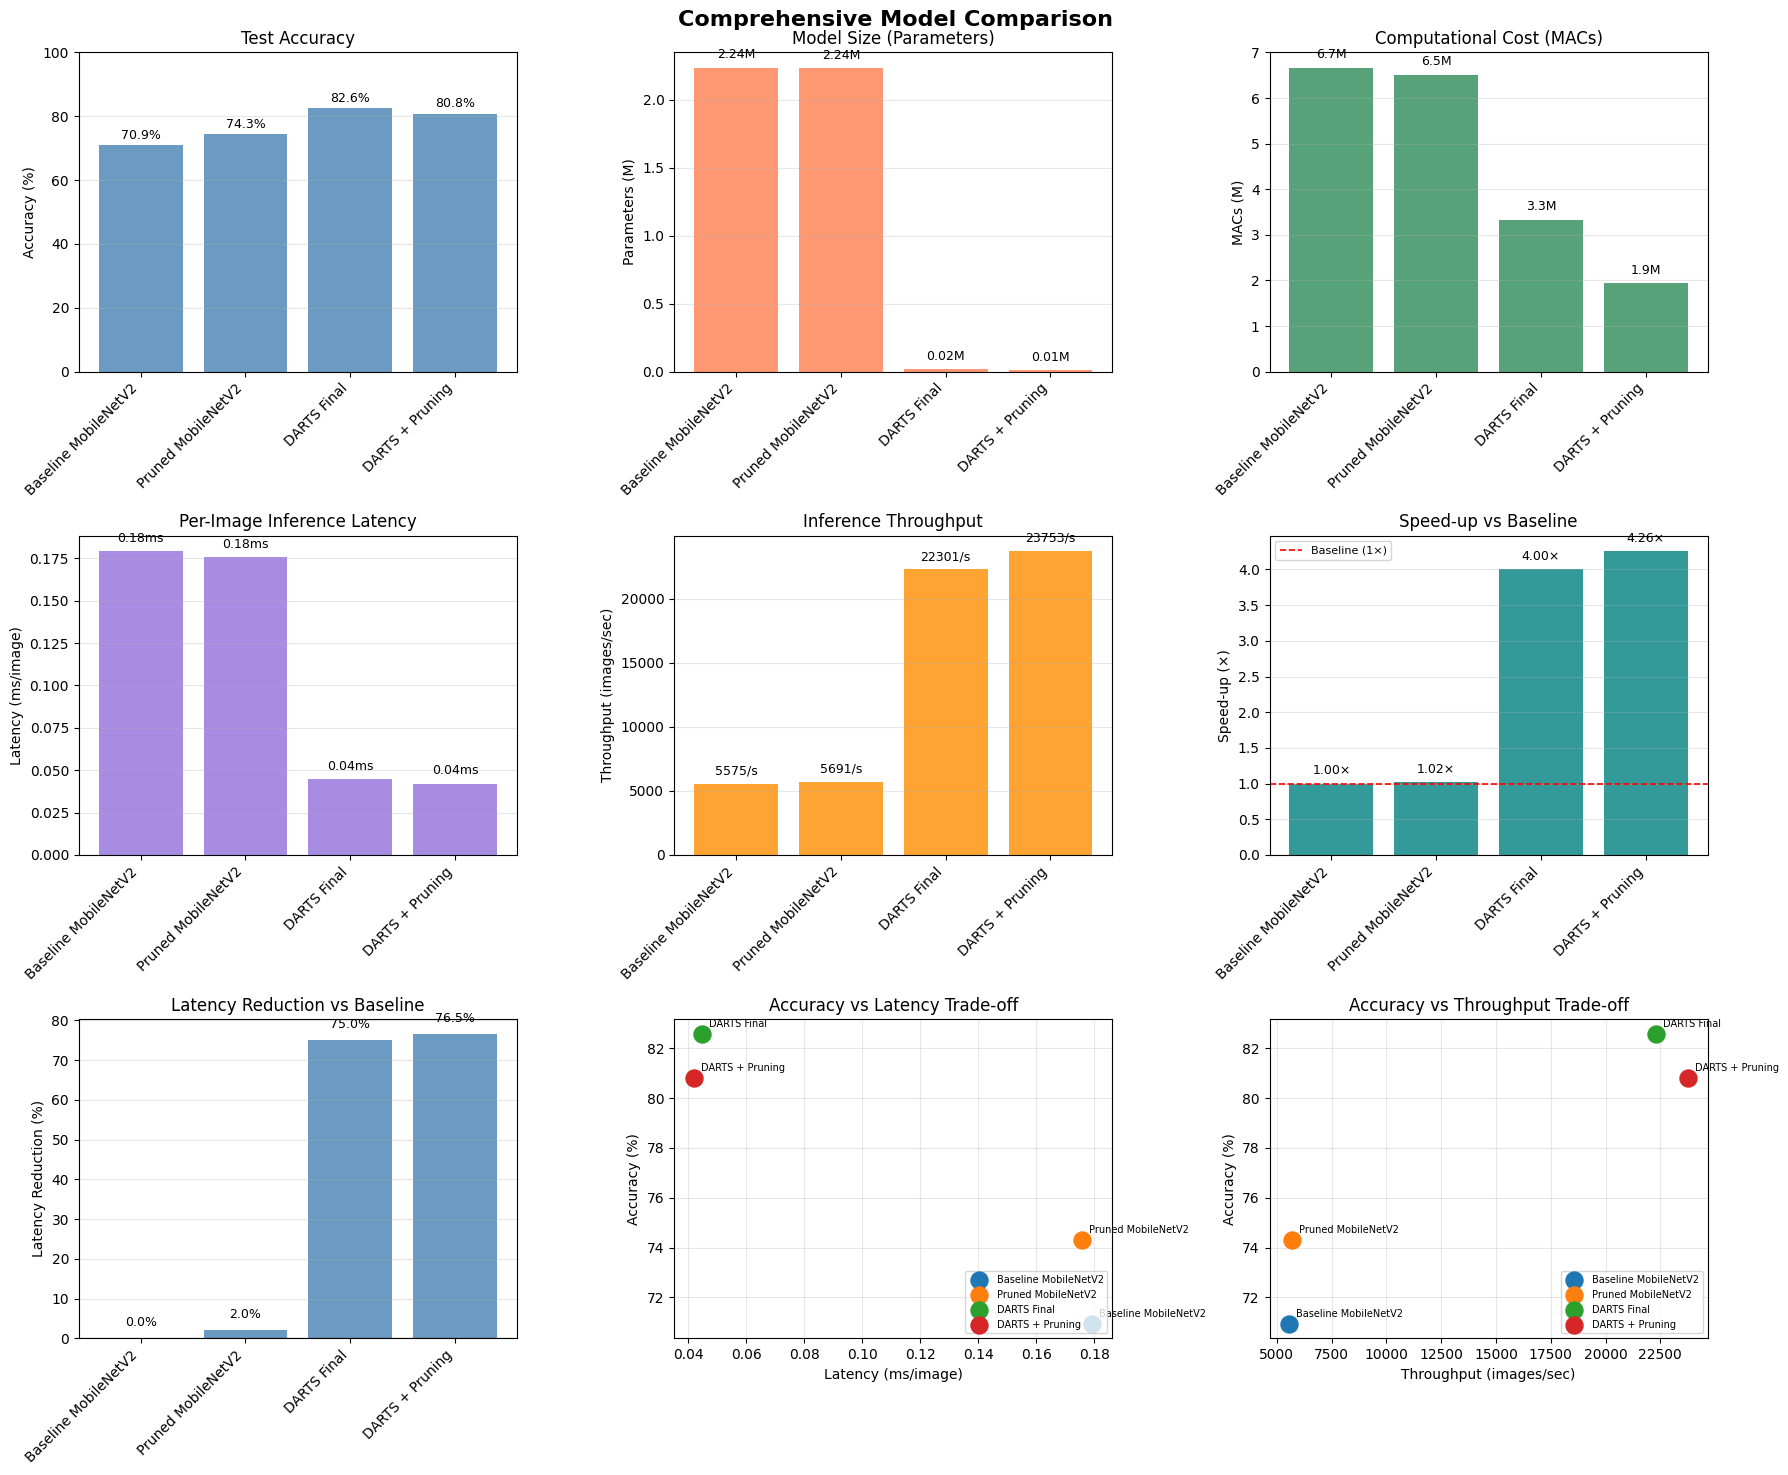

✅ Radar chart saved to ./results/radar_chart.png


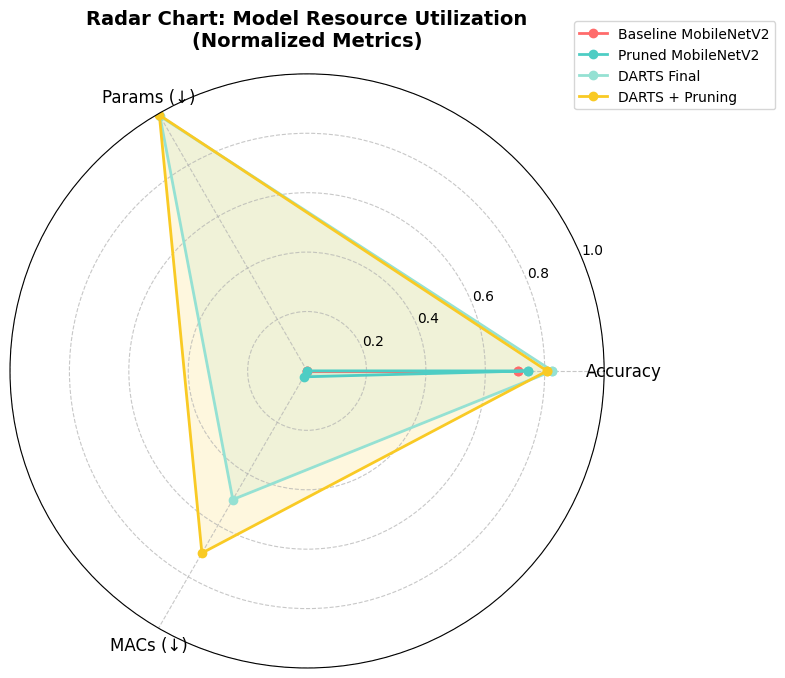

✅ Figure saved to ./results/efficiency_frontier.png


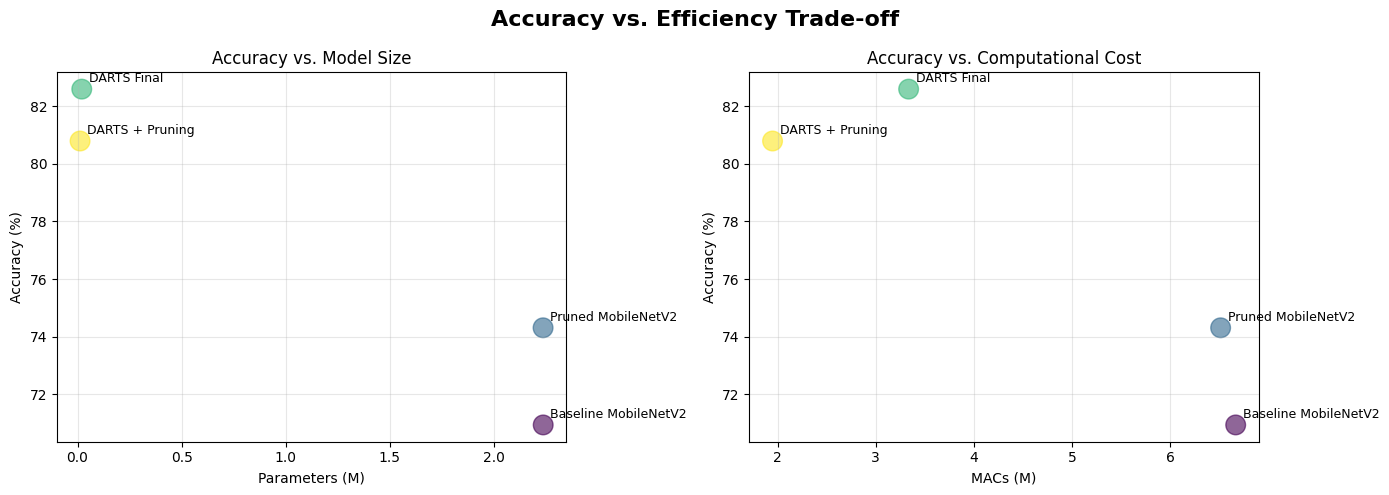

In [ ]:
"""
Cell 11: Comprehensive Model Comparison
========================================
Compare all model variants and visualize results.
"""

import torch
import torch.nn as nn
import os
import numpy as np
import matplotlib.pyplot as plt
from typing import Dict


# ============================================================================
# IMPORTS (Add at top)
# ============================================================================




# ============================================================================
# COMPARISON (FIXED - LOADS ALL 4 MODELS)
# ============================================================================

def compare_all_models(config, testloader):
    """
    Load and compare all trained models.
    FIXED: Now properly loads all 4 models including pruned variants.

    Args:
        config: Configuration object
        testloader: Test data loader

    Returns:
        Dictionary with all metrics
    """
    all_metrics = {}

    print("\n" + "="*70)
    print("COMPREHENSIVE MODEL COMPARISON")
    print("="*70)

    # ========================================
    # 1. Baseline MobileNetV2
    # ========================================
    baseline_path = os.path.join(config.MODEL_DIR, 'baseline_mobilenetv2.pth')
    baseline_model = None  # Keep reference for pruned version

    if os.path.exists(baseline_path):
        print("\n📊 Loading Baseline MobileNetV2...")
        baseline_model = get_mobilenet_v2(
        num_classes=10,
        pretrained=False,
        width_mult=0.7   # 🔥 IMPORTANT FIX
        )
        baseline_model.load_state_dict(torch.load(baseline_path, map_location=config.DEVICE))
        # Collect baseline metrics first (no reference, so speedup=1x, latency reduction=0%)
        metrics = collect_metrics(baseline_model, testloader, config, "Baseline MobileNetV2",
                                  baseline_inf_time_ms=None)
        all_metrics['baseline'] = metrics
        _baseline_inf_time_ms = metrics['inf_time_ms']  # store for downstream comparisons
        print_metrics(metrics)
    else:
        print(f"⚠️  Baseline model not found at {baseline_path}")
        _baseline_inf_time_ms = None

    # ========================================
    # 2. Pruned MobileNetV2 (FIXED!)
    # ========================================
    pruned_path = os.path.join(config.MODEL_DIR, 'pruned_mobilenetv2_finetuned.pth')

    if os.path.exists(pruned_path) and baseline_model is not None:
        print("\n📊 Loading Pruned MobileNetV2...")

        try:
            # Rebuild pruned architecture from baseline
            print("   Rebuilding pruned architecture...")
            pruned_model, masks = prune_model(baseline_model, config)

            # Check if pruning actually worked (model is different)
            baseline_params = sum(p.numel() for p in baseline_model.parameters())
            pruned_params = sum(p.numel() for p in pruned_model.parameters())

            if pruned_params < baseline_params:
                # Pruning worked, load fine-tuned weights
                print(f"   Loading fine-tuned weights ({pruned_params:,} params)...")
                pruned_model.load_state_dict(torch.load(pruned_path, map_location=config.DEVICE))

                metrics = collect_metrics(pruned_model, testloader, config, "Pruned MobileNetV2",
                                          baseline_inf_time_ms=_baseline_inf_time_ms)
                all_metrics['pruned_mobilenet'] = metrics
                print_metrics(metrics)
            else:
                print(f"   ⚠️  Pruning validation failed (same size as baseline)")
                print(f"   Skipping pruned model (would be duplicate)")

        except Exception as e:
            print(f"   ⚠️  Could not load pruned model: {e}")
    else:
        if not os.path.exists(pruned_path):
            print(f"\n⚠️  Pruned model not found at {pruned_path}")
        elif baseline_model is None:
            print(f"\n⚠️  Cannot load pruned model without baseline")

    # ========================================
    # 3. DARTS Final Network
    # ========================================
    darts_path = os.path.join(config.MODEL_DIR, 'darts_final_network.pth')
    darts_model = None  # Keep reference for pruned version
    darts_genotype = None

    if os.path.exists(darts_path):
        print("\n📊 Loading DARTS Final Network...")
        checkpoint = torch.load(darts_path, map_location=config.DEVICE)
        darts_genotype = checkpoint['genotype']

        darts_model = DARTSFinalNetwork(
            genotype=darts_genotype,
            init_channels=config.DARTS_INIT_CHANNELS,
            num_classes=config.NUM_CLASSES
        )
        darts_model.load_state_dict(checkpoint['state_dict'])

        metrics = collect_metrics(darts_model, testloader, config, "DARTS Final",
                                  baseline_inf_time_ms=_baseline_inf_time_ms if 'baseline' in all_metrics else None)
        all_metrics['darts_final'] = metrics
        print_metrics(metrics)
    else:
        print(f"⚠️  DARTS model not found at {darts_path}")

    # ========================================
    # 4. DARTS + Pruning (FIXED!)
    # ========================================
    darts_pruned_path = os.path.join(config.MODEL_DIR, 'darts_pruned_finetuned.pth')

    if os.path.exists(darts_pruned_path) and darts_model is not None:
        print("\n📊 Loading DARTS + Pruning...")

        try:
            # Rebuild pruned DARTS architecture
            print("   Rebuilding pruned DARTS architecture...")
            pruned_darts, masks = prune_darts_network(darts_model, config)

            # Check if pruning actually worked
            darts_params = sum(p.numel() for p in darts_model.parameters())
            pruned_darts_params = sum(p.numel() for p in pruned_darts.parameters())

            if pruned_darts_params < darts_params:
                # Pruning worked, load fine-tuned weights
                print(f"   Loading fine-tuned weights ({pruned_darts_params:,} params)...")
                pruned_darts.load_state_dict(torch.load(darts_pruned_path, map_location=config.DEVICE))

                metrics = collect_metrics(pruned_darts, testloader, config, "DARTS + Pruning",
                                          baseline_inf_time_ms=_baseline_inf_time_ms if 'baseline' in all_metrics else None)
                all_metrics['darts_pruned'] = metrics
                print_metrics(metrics)
            else:
                print(f"   ⚠️  Pruning validation failed (same size as original)")
                print(f"   Skipping pruned DARTS (would be duplicate)")

        except Exception as e:
            print(f"   ⚠️  Could not load pruned DARTS: {e}")
    else:
        if not os.path.exists(darts_pruned_path):
            print(f"\n⚠️  Pruned DARTS model not found at {darts_pruned_path}")
        elif darts_model is None:
            print(f"\n⚠️  Cannot load pruned DARTS without original DARTS model")

    return all_metrics


# ============================================================================
# VISUALIZATION
# ============================================================================

def plot_comparison(metrics_dict, save_path=None):
    """
    Create comprehensive comparison plots including throughput, speed-up, and latency reduction.

    Args:
        metrics_dict: Dictionary mapping model names to metrics
        save_path: Optional path to save figure
    """
    if len(metrics_dict) == 0:
        print("⚠️  No metrics to plot")
        return

    # Extract data
    labels = [m['label'] for m in metrics_dict.values()]
    accuracies = [m['val_acc'] for m in metrics_dict.values()]
    params = [m['total_params'] for m in metrics_dict.values()]
    macs = [m['macs'] for m in metrics_dict.values()]
    inf_times = [m['inf_time_ms'] for m in metrics_dict.values()]
    throughputs = [m.get('throughput_imgs_sec', float('nan')) for m in metrics_dict.values()]
    speedups = [m.get('speedup', 1.0) for m in metrics_dict.values()]
    lat_reds = [m.get('latency_reduction_pct', 0.0) for m in metrics_dict.values()]

    # Create figure with subplots (3x3 grid for extra metrics)
    fig, axes = plt.subplots(3, 3, figsize=(18, 15))
    fig.suptitle('Comprehensive Model Comparison', fontsize=16, fontweight='bold')

    # 1. Accuracy comparison
    ax = axes[0, 0]
    bars = ax.bar(range(len(labels)), accuracies, color='steelblue', alpha=0.8)
    ax.set_xticks(range(len(labels)))
    ax.set_xticklabels(labels, rotation=45, ha='right')
    ax.set_ylabel('Accuracy (%)')
    ax.set_title('Test Accuracy')
    ax.set_ylim(0, 100)
    ax.grid(axis='y', alpha=0.3)
    for bar, val in zip(bars, accuracies):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
                f'{val:.1f}%', ha='center', va='bottom', fontsize=9)

    # 2. Parameters comparison
    ax = axes[0, 1]
    params_m = [p / 1e6 for p in params]
    bars = ax.bar(range(len(labels)), params_m, color='coral', alpha=0.8)
    ax.set_xticks(range(len(labels)))
    ax.set_xticklabels(labels, rotation=45, ha='right')
    ax.set_ylabel('Parameters (M)')
    ax.set_title('Model Size (Parameters)')
    ax.grid(axis='y', alpha=0.3)
    for bar, val in zip(bars, params_m):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + max(params_m)*0.02,
                f'{val:.2f}M', ha='center', va='bottom', fontsize=9)

    # 3. FLOPs comparison
    ax = axes[0, 2]
    macs_m = [m / 1e6 for m in macs]
    bars = ax.bar(range(len(labels)), macs_m, color='seagreen', alpha=0.8)
    ax.set_xticks(range(len(labels)))
    ax.set_xticklabels(labels, rotation=45, ha='right')
    ax.set_ylabel('MACs (M)')
    ax.set_title('Computational Cost (MACs)')
    ax.grid(axis='y', alpha=0.3)
    for bar, val in zip(bars, macs_m):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + max(macs_m)*0.02,
                f'{val:.1f}M', ha='center', va='bottom', fontsize=9)

    # 4. Per-image latency
    ax = axes[1, 0]
    bars = ax.bar(range(len(labels)), inf_times, color='mediumpurple', alpha=0.8)
    ax.set_xticks(range(len(labels)))
    ax.set_xticklabels(labels, rotation=45, ha='right')
    ax.set_ylabel('Latency (ms/image)')
    ax.set_title('Per-Image Inference Latency')
    ax.grid(axis='y', alpha=0.3)
    for bar, val in zip(bars, inf_times):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + max(inf_times)*0.02,
                f'{val:.2f}ms', ha='center', va='bottom', fontsize=9)

    # 5. Throughput (images/sec)
    ax = axes[1, 1]
    bars = ax.bar(range(len(labels)), throughputs, color='darkorange', alpha=0.8)
    ax.set_xticks(range(len(labels)))
    ax.set_xticklabels(labels, rotation=45, ha='right')
    ax.set_ylabel('Throughput (images/sec)')
    ax.set_title('Inference Throughput')
    ax.grid(axis='y', alpha=0.3)
    valid_t = [t for t in throughputs if not (t != t)]  # filter NaN
    max_t = max(valid_t) if valid_t else 1
    for bar, val in zip(bars, throughputs):
        if val == val:  # not NaN
            ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + max_t*0.02,
                    f'{val:.0f}/s', ha='center', va='bottom', fontsize=9)

    # 6. Speed-up vs Baseline
    ax = axes[1, 2]
    bars = ax.bar(range(len(labels)), speedups, color='teal', alpha=0.8)
    ax.axhline(y=1.0, color='red', linestyle='--', linewidth=1.2, label='Baseline (1×)')
    ax.set_xticks(range(len(labels)))
    ax.set_xticklabels(labels, rotation=45, ha='right')
    ax.set_ylabel('Speed-up (×)')
    ax.set_title('Speed-up vs Baseline')
    ax.grid(axis='y', alpha=0.3)
    ax.legend(fontsize=8)
    for bar, val in zip(bars, speedups):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + max(speedups)*0.02,
                f'{val:.2f}×', ha='center', va='bottom', fontsize=9)

    # 7. Latency Reduction %
    ax = axes[2, 0]
    colors_lr = ['steelblue' if v >= 0 else 'tomato' for v in lat_reds]
    bars = ax.bar(range(len(labels)), lat_reds, color=colors_lr, alpha=0.8)
    ax.axhline(y=0, color='black', linewidth=0.8)
    ax.set_xticks(range(len(labels)))
    ax.set_xticklabels(labels, rotation=45, ha='right')
    ax.set_ylabel('Latency Reduction (%)')
    ax.set_title('Latency Reduction vs Baseline')
    ax.grid(axis='y', alpha=0.3)
    offset = max(abs(v) for v in lat_reds) * 0.03 if lat_reds else 1
    for bar, val in zip(bars, lat_reds):
        y_pos = bar.get_height() + offset if val >= 0 else bar.get_height() - offset
        ax.text(bar.get_x() + bar.get_width()/2, y_pos,
                f'{val:.1f}%', ha='center', va='bottom', fontsize=9)

    # 8. Accuracy vs Latency scatter
    ax = axes[2, 1]
    cmap = plt.cm.tab10
    for idx, (label, inf_t, acc) in enumerate(zip(labels, inf_times, accuracies)):
        ax.scatter(inf_t, acc, s=150, color=cmap(idx), zorder=3, label=label)
        ax.annotate(label, (inf_t, acc), textcoords='offset points', xytext=(5, 5), fontsize=7)
    ax.set_xlabel('Latency (ms/image)')
    ax.set_ylabel('Accuracy (%)')
    ax.set_title('Accuracy vs Latency Trade-off')
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=7, loc='lower right')

    # 9. Accuracy vs Throughput scatter
    ax = axes[2, 2]
    for idx, (label, tpt, acc) in enumerate(zip(labels, throughputs, accuracies)):
        if tpt == tpt:  # not NaN
            ax.scatter(tpt, acc, s=150, color=cmap(idx), zorder=3, label=label)
            ax.annotate(label, (tpt, acc), textcoords='offset points', xytext=(5, 5), fontsize=7)
    ax.set_xlabel('Throughput (images/sec)')
    ax.set_ylabel('Accuracy (%)')
    ax.set_title('Accuracy vs Throughput Trade-off')
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=7, loc='lower right')

    plt.tight_layout()

    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
        print(f"✅ Figure saved to {save_path}")

    plt.show()


def plot_radar_chart(metrics_dict, save_path=None):
    """
    Create radar chart comparing normalized metrics.
    Similar to the image you provided.

    Args:
        metrics_dict: Dictionary mapping model names to metrics
        save_path: Optional path to save figure
    """
    if len(metrics_dict) == 0:
        print("⚠️  No metrics to plot")
        return

    # Extract and normalize metrics (0-1 scale)
    labels = [m['label'] for m in metrics_dict.values()]

    # Get raw values
    accuracies = np.array([m['val_acc'] for m in metrics_dict.values()])
    params = np.array([m['total_params'] for m in metrics_dict.values()])
    macs = np.array([m['macs'] for m in metrics_dict.values()])

    # Normalize to 0-1 (higher is better for accuracy, lower is better for params/macs)
    # Accuracy: normalize to 0-1
    acc_norm = accuracies / 100.0

    # Params: invert so smaller is better (1 - normalized)
    params_norm = 1.0 - (params / params.max())

    # MACs: invert so smaller is better
    macs_norm = 1.0 - (macs / macs.max())

    # Setup radar chart
    categories = ['Accuracy', 'Params (↓)', 'MACs (↓)']
    num_vars = len(categories)

    # Compute angle for each axis
    angles = np.linspace(0, 2 * np.pi, num_vars, endpoint=False).tolist()
    angles += angles[:1]  # Complete the circle

    # Create figure
    fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(projection='polar'))

    # Colors for each model
    colors = ['#FF6B6B', '#4ECDC4', '#95E1D3', '#F9CA24']

    # Plot each model
    for idx, label in enumerate(labels):
        values = [acc_norm[idx], params_norm[idx], macs_norm[idx]]
        values += values[:1]  # Complete the circle

        ax.plot(angles, values, 'o-', linewidth=2, label=label, color=colors[idx % len(colors)])
        ax.fill(angles, values, alpha=0.15, color=colors[idx % len(colors)])

    # Customize chart
    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(categories, size=12)
    ax.set_ylim(0, 1)
    ax.set_yticks([0.2, 0.4, 0.6, 0.8, 1.0])
    ax.set_yticklabels(['0.2', '0.4', '0.6', '0.8', '1.0'], size=10)
    ax.grid(True, linestyle='--', alpha=0.7)

    # Add title and legend
    plt.title('Radar Chart: Model Resource Utilization\n(Normalized Metrics)',
              size=14, fontweight='bold', pad=20)
    plt.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1))

    plt.tight_layout()

    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
        print(f"✅ Radar chart saved to {save_path}")

    plt.show()


def plot_efficiency_frontier(metrics_dict, save_path=None):
    """
    Plot accuracy vs. efficiency (params and FLOPs).

    Args:
        metrics_dict: Dictionary mapping model names to metrics
        save_path: Optional path to save figure
    """
    if len(metrics_dict) == 0:
        print("⚠️  No metrics to plot")
        return

    # Extract data
    labels = [m['label'] for m in metrics_dict.values()]
    accuracies = [m['val_acc'] for m in metrics_dict.values()]
    params = [m['total_params'] / 1e6 for m in metrics_dict.values()]  # Millions
    macs = [m['macs'] / 1e6 for m in metrics_dict.values()]  # Millions

    # Create figure
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle('Accuracy vs. Efficiency Trade-off', fontsize=16, fontweight='bold')

    # 1. Accuracy vs. Parameters
    ax1.scatter(params, accuracies, s=200, alpha=0.6, c=range(len(labels)), cmap='viridis')
    for i, label in enumerate(labels):
        ax1.annotate(label, (params[i], accuracies[i]),
                    xytext=(5, 5), textcoords='offset points', fontsize=9)
    ax1.set_xlabel('Parameters (M)')
    ax1.set_ylabel('Accuracy (%)')
    ax1.set_title('Accuracy vs. Model Size')
    ax1.grid(True, alpha=0.3)

    # 2. Accuracy vs. FLOPs
    ax2.scatter(macs, accuracies, s=200, alpha=0.6, c=range(len(labels)), cmap='viridis')
    for i, label in enumerate(labels):
        ax2.annotate(label, (macs[i], accuracies[i]),
                    xytext=(5, 5), textcoords='offset points', fontsize=9)
    ax2.set_xlabel('MACs (M)')
    ax2.set_ylabel('Accuracy (%)')
    ax2.set_title('Accuracy vs. Computational Cost')
    ax2.grid(True, alpha=0.3)

    plt.tight_layout()

    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
        print(f"✅ Figure saved to {save_path}")

    plt.show()


def generate_comparison_table(metrics_dict):
    """
    Generate a formatted comparison table including throughput, speed, and latency reduction.

    Args:
        metrics_dict: Dictionary mapping model names to metrics
    """
    print("\n" + "="*120)
    print("COMPREHENSIVE COMPARISON TABLE")
    print("="*120)
    print(f"{'Model':<30s} {'Accuracy':>10s} {'Params':>10s} {'MACs':>10s} "
          f"{'Latency':>12s} {'Throughput':>15s} {'Speed-up':>10s} {'Lat.Red.':>10s}")
    print("-"*120)

    for metrics in metrics_dict.values():
        label = metrics['label']
        acc = metrics['val_acc']
        params = metrics['total_params'] / 1e6
        macs = metrics['macs'] / 1e6
        latency = metrics['inf_time_ms']
        throughput = metrics.get('throughput_imgs_sec', float('nan'))
        speedup = metrics.get('speedup', 1.0)
        lat_red = metrics.get('latency_reduction_pct', 0.0)

        print(f"{label:<30s} {acc:>9.2f}% {params:>8.2f}M {macs:>8.1f}M "
              f"{latency:>10.2f}ms {throughput:>13.0f}/s {speedup:>9.2f}x {lat_red:>9.1f}%")

    print("="*120)


# ============================================================================
# MAIN EXECUTION
# ============================================================================

if __name__ == "__main__":
    # Setup
    set_seed(Config.SEED)
    setup_directories()

    # Load data
    _, _, testloader, _, _ = load_cifar10(Config)

    # Compare all models
    metrics_dict = compare_all_models(Config, testloader)

    if len(metrics_dict) > 0:
        # Generate comparison table
        generate_comparison_table(metrics_dict)

        # Create visualizations
        plot_save_path = os.path.join(Config.RESULTS_DIR, 'model_comparison.png')
        plot_comparison(metrics_dict, save_path=plot_save_path)

        # NEW: Radar chart
        radar_save_path = os.path.join(Config.RESULTS_DIR, 'radar_chart.png')
        plot_radar_chart(metrics_dict, save_path=radar_save_path)

        efficiency_save_path = os.path.join(Config.RESULTS_DIR, 'efficiency_frontier.png')
        plot_efficiency_frontier(metrics_dict, save_path=efficiency_save_path)
    else:
        print("⚠️  No models found for comparison. Please train models first.")


🚀🚀🚀🚀🚀🚀🚀🚀🚀🚀🚀🚀🚀🚀🚀🚀🚀🚀🚀🚀🚀🚀🚀🚀🚀🚀🚀🚀🚀🚀🚀🚀🚀🚀🚀🚀🚀🚀🚀🚀
                         NAS + PRUNING PIPELINE
🚀🚀🚀🚀🚀🚀🚀🚀🚀🚀🚀🚀🚀🚀🚀🚀🚀🚀🚀🚀🚀🚀🚀🚀🚀🚀🚀🚀🚀🚀🚀🚀🚀🚀🚀🚀🚀🚀🚀🚀

CONFIGURATION
BASELINE_EPOCHS               : 50
BASELINE_GAMMA                : 0.1
BASELINE_LR                   : 0.1
BASELINE_MILESTONES           : [25, 40]
BASELINE_MOMENTUM             : 0.9
BASELINE_WEIGHT_DECAY         : 0.0005
BATCH_SIZE                    : 128
DARTS_ARCH_LR                 : 0.0003
DARTS_ARCH_WEIGHT_DECAY       : 0.001
DARTS_FINETUNE_EPOCHS         : 30
DARTS_FINETUNE_LR             : 0.01
DARTS_FINETUNE_WEIGHT_DECAY   : 0.0001
DARTS_INIT_CHANNELS           : 16
DARTS_LAYERS                  : 6
DARTS_PRUNE_AMOUNT            : 0.3
DARTS_SEARCH_BATCHES_PER_EPOCH: 50
DARTS_SEARCH_EPOCHS           : 50
DARTS_TRAIN_EPOCHS            : 50
DARTS_TRAIN_GAMMA             : 0.1
DARTS_TRAIN_LR                : 0.025
DARTS_TRAIN_MILESTONES        : [25, 40]
DARTS_TRAIN_MOMENTUM          : 0.9
DARTS_TRAIN_WEIGHT_DECAY      : 0.0003
DARTS_W

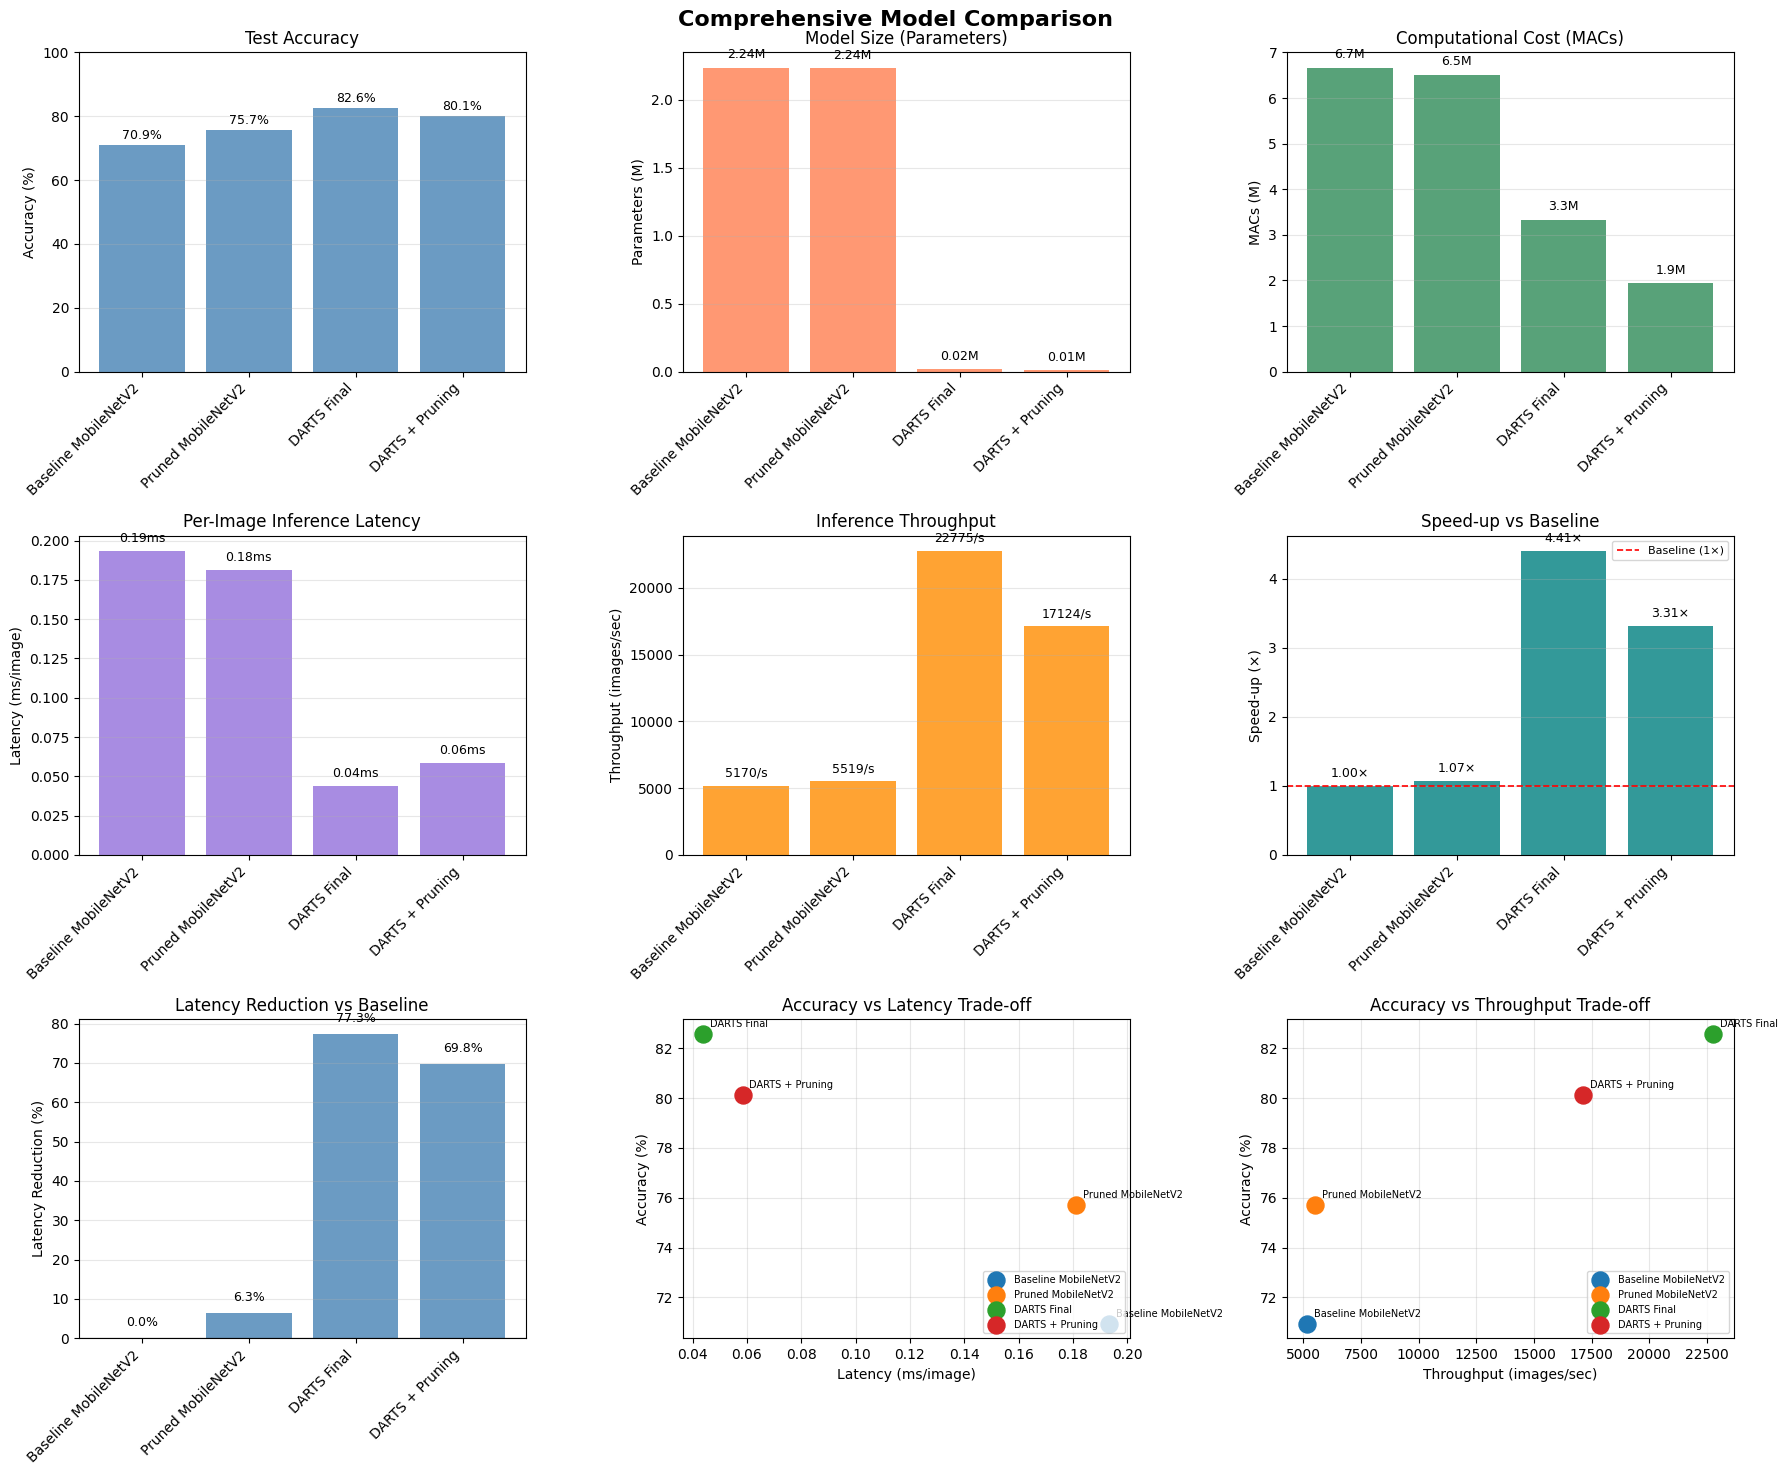

✅ Figure saved to ./results/efficiency_frontier.png


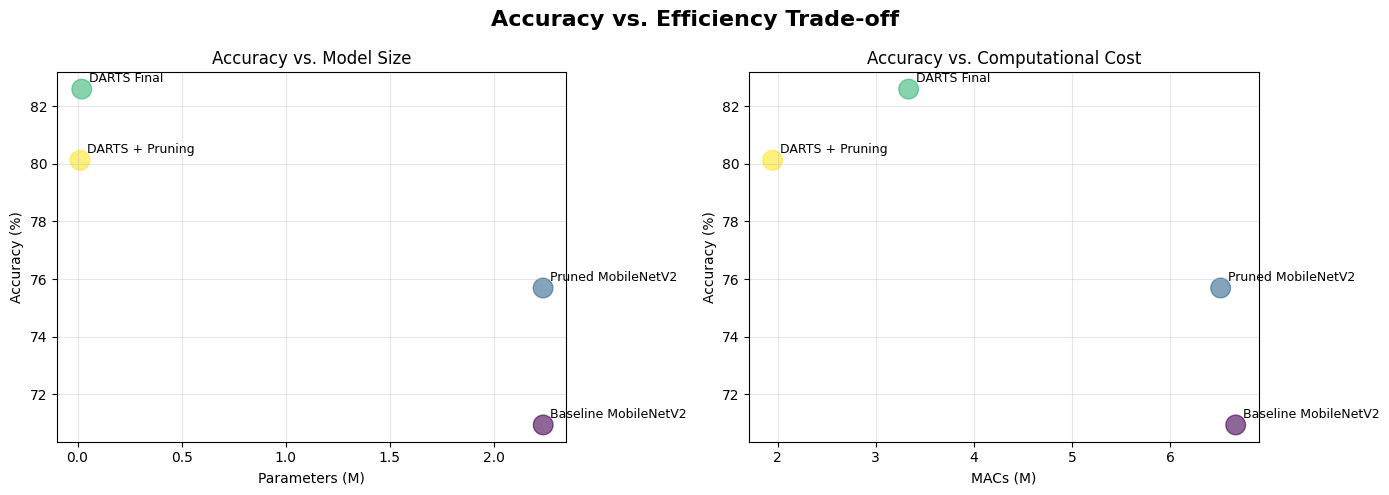


🎉🎉🎉🎉🎉🎉🎉🎉🎉🎉🎉🎉🎉🎉🎉🎉🎉🎉🎉🎉🎉🎉🎉🎉🎉🎉🎉🎉🎉🎉🎉🎉🎉🎉🎉🎉🎉🎉🎉🎉
                         PIPELINE COMPLETE!
🎉🎉🎉🎉🎉🎉🎉🎉🎉🎉🎉🎉🎉🎉🎉🎉🎉🎉🎉🎉🎉🎉🎉🎉🎉🎉🎉🎉🎉🎉🎉🎉🎉🎉🎉🎉🎉🎉🎉🎉

📁 Generated Files:
   Models:  ./models/
   Results: ./results/

📊 Final Summary:
   Baseline MobileNetV2     : 70.94% accuracy, 2.24M params, 6.7M MACs
   Pruned MobileNetV2       : 75.69% accuracy, 2.24M params, 6.5M MACs
   DARTS Final              : 82.59% accuracy, 0.02M params, 3.3M MACs
   DARTS + Pruning          : 80.12% accuracy, 0.01M params, 1.9M MACs

✅ All done!


In [ ]:
import argparse
import os
import sys
import torch # Explicitly import torch

# Import all cells (assuming these are functions/classes defined in prior executed cells)
# from uKrrEaxP0BZ7 import Config, set_seed, setup_directories
# from mFaBPNpL0Kx_ import load_cifar10, get_full_trainloader
# from q8nRvK7f0PHT import collect_metrics, print_metrics
# from tUrhDsVX2ueY import train_baseline, get_mobilenet_v2
# from q4XDsk8c09ri import prune_model, finetune_pruned_model # Re-added pruned_model and finetune_pruned_model
# from yIxTFs5k1tLd import search_architecture, load_genotype # Re-added search_architecture and load_genotype
# from Nt82LdsB1u_8 import train_darts_final # Re-added train_darts_final
# from SyfWsu5h1zPy import darts_pruning_pipeline # Re-added darts_pruning_pipeline
# from _ZAglpFo12TC import compare_all_models, plot_comparison, plot_efficiency_frontier, generate_comparison_table # Re-added all comparison functions

# Explicitly import DARTSFinalNetwork as it's needed in run_complete_pipeline
# from b4pxXlM51pjd import DARTSSearchNetwork, DARTSFinalNetwork, get_operations, MixedOp, SepConv, DilConv, Identity, PoolBN

# Global objects expected to be available from previous cells:
# Config, set_seed, setup_directories
# load_cifar10, get_full_trainloader
# collect_metrics, print_metrics
# train_baseline, get_mobilenet_v2
# prune_model, finetune_pruned_model
# search_architecture, load_genotype
# train_darts_final
# darts_pruning_pipeline
# compare_all_models, plot_comparison, plot_efficiency_frontier, generate_comparison_table
# DARTSSearchNetwork, DARTSFinalNetwork, get_operations, MixedOp, SepConv, DilConv, Identity, PoolBN

def modify_config_for_quick_test(config):
    """Reduce epochs for quick testing."""
    config.BASELINE_EPOCHS = 5
    config.FINETUNE_EPOCHS = 5
    config.DARTS_SEARCH_EPOCHS = 5
    config.DARTS_SEARCH_BATCHES_PER_EPOCH = 10
    config.DARTS_TRAIN_EPOCHS = 5
    config.DARTS_FINETUNE_EPOCHS = 5
    print("⚡ QUICK MODE: Reduced epochs for testing")


def print_section_header(title):
    """Print a formatted section header."""
    print("\n" + "="*80)
    print(f"  {title}")
    print("="*80 + "\n")


def run_complete_pipeline(quick_mode=False):
    """
    Execute the complete NAS + Pruning pipeline.

    Args:
        quick_mode: If True, use reduced epochs for quick testing
    """
    print("\n" + "🚀"*40)
    print(" "*25 + "NAS + PRUNING PIPELINE")
    print("🚀"*40 + "\n")

    # Setup
    if quick_mode:
        modify_config_for_quick_test(Config)

    Config.print_config()
    set_seed(Config.SEED)
    setup_directories()

    # ========================================
    # PHASE 1: Data Loading
    # ========================================
    print_section_header("PHASE 1: Data Loading")

    trainloader_search, validloader, testloader, train_dataset, test_dataset = load_cifar10(Config)
    trainloader_full = get_full_trainloader(train_dataset, Config)

    print(f"✅ Training samples (full): {len(train_dataset)}")
    print(f"✅ Training samples (search): {len(trainloader_search.sampler)}")
    print(f"✅ Validation samples: {len(validloader.sampler)}")
    print(f"✅ Test samples: {len(test_dataset)}")

    # ========================================
    # PHASE 2: Baseline Training
    # ========================================
    print_section_header("PHASE 2: Baseline MobileNetV2 Training")

    baseline_path = os.path.join(Config.MODEL_DIR, 'baseline_mobilenetv2.pth')

    if os.path.exists(baseline_path) and not quick_mode:
        print(f"✅ Loading existing baseline model from {baseline_path}")
        baseline_model = get_mobilenet_v2(num_classes=Config.NUM_CLASSES, pretrained=False)
        baseline_model.load_state_dict(torch.load(baseline_path, map_location=Config.DEVICE))
    else:
        baseline_model = train_baseline(Config, trainloader_full, testloader, baseline_path)

    baseline_metrics = collect_metrics(baseline_model, testloader, Config, "Baseline MobileNetV2",
                                       baseline_inf_time_ms=None)
    _baseline_inf_time_ms = baseline_metrics['inf_time_ms']
    print_metrics(baseline_metrics)

    # ========================================
    # PHASE 3: Pruning Baseline
    # ========================================
    print_section_header("PHASE 3: Structured Pruning of Baseline")

    pruned_model, masks = prune_model(baseline_model, Config)

    print("\n📊 Evaluating pruned model (before fine-tuning)...")
    pruned_metrics_before = collect_metrics(pruned_model, testloader, Config, "Pruned (Before FT)",
                                            baseline_inf_time_ms=_baseline_inf_time_ms)
    print_metrics(pruned_metrics_before)

    pruned_path = os.path.join(Config.MODEL_DIR, 'pruned_mobilenetv2_finetuned.pth')
    pruned_model = finetune_pruned_model(pruned_model, trainloader_full, testloader, Config, pruned_path)

    pruned_metrics_after = collect_metrics(pruned_model, testloader, Config, "Pruned (After FT)",
                                           baseline_inf_time_ms=_baseline_inf_time_ms)
    print_metrics(pruned_metrics_after)

    # ========================================
    # PHASE 4: DARTS Architecture Search
    # ========================================
    print_section_header("PHASE 4: DARTS Architecture Search")

    search_path = os.path.join(Config.MODEL_DIR, 'darts_search_network.pth')

    if os.path.exists(search_path) and not quick_mode:
        print(f"✅ Loading existing search network from {search_path}")
        genotype = load_genotype(search_path)
        print(f"   Genotype: {genotype}")
    else:
        search_net = search_architecture(trainloader_search, validloader, Config, search_path)
        genotype = search_net.genotype()

    # ========================================
    # PHASE 5: Train Final DARTS Network
    # ========================================
    print_section_header("PHASE 5: Train Final DARTS Network")

    darts_path = os.path.join(Config.MODEL_DIR, 'darts_final_network.pth')

    if os.path.exists(darts_path) and not quick_mode:
        print(f"✅ Loading existing DARTS model from {darts_path}")
        checkpoint = torch.load(darts_path, map_location=Config.DEVICE)
        genotype = checkpoint['genotype']
        darts_model = DARTSFinalNetwork(
            genotype=genotype,
            init_channels=Config.DARTS_INIT_CHANNELS,
            num_classes=Config.NUM_CLASSES
        )
        darts_model.load_state_dict(checkpoint['state_dict'])
    else:
        darts_model = train_darts_final(genotype, trainloader_full, testloader, Config, darts_path)

    darts_metrics = collect_metrics(darts_model, testloader, Config, "DARTS Final",
                                   baseline_inf_time_ms=_baseline_inf_time_ms)
    print_metrics(darts_metrics)

    # ========================================
    # PHASE 6: DARTS + Pruning Combined
    # ========================================
    print_section_header("PHASE 6: DARTS + Pruning (Key Innovation)")

    results = darts_pruning_pipeline(darts_model, trainloader_full, testloader, Config)

    # ========================================
    # PHASE 7: Comprehensive Comparison
    # ========================================
    print_section_header("PHASE 7: Final Comparison & Visualization")

    all_metrics = compare_all_models(Config, testloader)

    if len(all_metrics) > 0:
        generate_comparison_table(all_metrics)

        plot_save_path = os.path.join(Config.RESULTS_DIR, 'model_comparison.png')
        plot_comparison(all_metrics, save_path=plot_save_path)

        efficiency_save_path = os.path.join(Config.RESULTS_DIR, 'efficiency_frontier.png')
        plot_efficiency_frontier(all_metrics, save_path=efficiency_save_path)

    # ========================================
    # SUMMARY
    # ========================================
    print("\n" + "🎉"*40)
    print(" "*25 + "PIPELINE COMPLETE!")
    print("🎉"*40)

    print("\n📁 Generated Files:")
    print(f"   Models:  {Config.MODEL_DIR}/")
    print(f"   Results: {Config.RESULTS_DIR}/")

    print("\n📊 Final Summary:")
    if len(all_metrics) > 0:
        for name, metrics in all_metrics.items():
            print(f"   {metrics['label']:<25s}: {metrics['val_acc']:.2f}% accuracy, "
                  f"{metrics['total_params']/1e6:.2f}M params, "
                  f"{metrics['macs']/1e6:.1f}M MACs")

    print("\n✅ All done!")


if __name__ == "__main__":
    parser = argparse.ArgumentParser(description='Run complete NAS + Pruning pipeline')
    parser.add_argument('--quick', action='store_true',
                       help='Run with reduced epochs for quick testing')

    # In Colab, sys.argv can contain kernel-related arguments.
    # To avoid 'unrecognized arguments' error, pass an empty list if no user-defined arguments are intended
    if '-f' in sys.argv:
        args = parser.parse_args([])
    else:
        args = parser.parse_args()

    try:
        run_complete_pipeline(quick_mode=args.quick)
    except KeyboardInterrupt:
        print("\n\n⚠️  Pipeline interrupted by user")
        sys.exit(1)
    except Exception as e:
        print(f"\n\n❌ Pipeline failed with error: {e}")
        import traceback
        traceback.print_exc()
        sys.exit(1)

In [ ]:
!pip install -q onnxruntime

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17.2/17.2 MB 81.1 MB/s eta 0:00:00


In [ ]:
#!/usr/bin/env python3
"""
export_12_models.py
====================
Exports all 12 model variants to ONNX format for Raspberry Pi deployment.

Models exported (12 total):
  Baseline MobileNetV2  x {FP32, INT8, Prep}  = 3
  DARTS Final           x {FP32, INT8, Prep}  = 3
  DARTS Pruned          x {FP32, INT8, Prep}  = 3
  Pruned MobileNetV2    x {FP32, INT8, Prep}  = 3

"Prep" = FP32 ONNX graph optimised + simplified (no quantization),
         used as an additional lightweight inference variant.

Requirements (install on the training machine, not the Pi):
    pip install torch torchvision onnx onnxruntime onnxsim

Usage:
    python export_12_models.py --models_dir ./models --output_dir ./onnx_edge_models

The exported files + a companion JSON manifest are written to --output_dir.
Transfer the whole folder to your Raspberry Pi and run benchmark_rpi.py there.
"""

import argparse
import json
import os
import copy
import sys
import time
import warnings

warnings.filterwarnings("ignore")

import numpy as np
import torch
import torch.nn as nn
import onnx

# ─────────────────────────────────────────────
# Re-use model definitions from the notebook
# (paste or import from your notebook cells)
# ─────────────────────────────────────────────
from torchvision import models


# ── MobileNetV2 ────────────────────────────────────────────────────────────────
def get_mobilenet_v2(num_classes: int = 10, pretrained: bool = False) -> nn.Module:
    model = models.mobilenet_v2(pretrained=pretrained)
    in_features = model.classifier[1].in_features
    model.classifier[1] = nn.Linear(in_features, num_classes)
    return model


# ── DARTS ops (minimal copy so this script is self-contained) ──────────────────
import torch.nn.functional as F


class SepConv(nn.Module):
    def __init__(self, C_in, C_out, kernel_size, stride, padding, affine=True):
        super().__init__()
        self.op = nn.Sequential(
            nn.ReLU(inplace=False),
            nn.Conv2d(C_in, C_in, kernel_size, stride, padding, groups=C_in, bias=False),
            nn.Conv2d(C_in, C_in, 1, padding=0, bias=False),
            nn.BatchNorm2d(C_in, affine=affine),
            nn.ReLU(inplace=False),
            nn.Conv2d(C_in, C_in, kernel_size, 1, padding, groups=C_in, bias=False),
            nn.Conv2d(C_in, C_out, 1, padding=0, bias=False),
            nn.BatchNorm2d(C_out, affine=affine),
        )

    def forward(self, x):
        return self.op(x)


class DilConv(nn.Module):
    def __init__(self, C_in, C_out, kernel_size, stride, padding, dilation=2, affine=True):
        super().__init__()
        self.op = nn.Sequential(
            nn.ReLU(inplace=False),
            nn.Conv2d(C_in, C_in, kernel_size, stride, padding, dilation=dilation, groups=C_in, bias=False),
            nn.Conv2d(C_in, C_out, 1, padding=0, bias=False),
            nn.BatchNorm2d(C_out, affine=affine),
        )

    def forward(self, x):
        return self.op(x)


class Identity(nn.Module):
    def __init__(self, C_in, C_out, stride):
        super().__init__()
        if C_in != C_out or stride != 1:
            self.adjust = nn.Sequential(
                nn.Conv2d(C_in, C_out, 1, stride=stride, bias=False),
                nn.BatchNorm2d(C_out),
            )
        else:
            self.adjust = None

    def forward(self, x):
        return x if self.adjust is None else self.adjust(x)


class PoolBN(nn.Module):
    def __init__(self, C_in, C_out, kernel_size, stride, padding):
        super().__init__()
        self.op = nn.Sequential(
            nn.MaxPool2d(kernel_size, stride=stride, padding=padding),
            nn.Conv2d(C_in, C_out, 1, bias=False),
            nn.BatchNorm2d(C_out),
        )

    def forward(self, x):
        return self.op(x)


def get_operations(C_in, C_out, stride):
    return {
        "sep_3x3": SepConv(C_in, C_out, 3, stride, 1),
        "sep_5x5": SepConv(C_in, C_out, 5, stride, 2),
        "dil_3x3": DilConv(C_in, C_out, 3, stride, 2, dilation=2),
        "identity": Identity(C_in, C_out, stride),
        "max_pool": PoolBN(C_in, C_out, 3, stride, 1),
    }


class DARTSFinalNetwork(nn.Module):
    def __init__(self, genotype, init_channels=16, num_classes=10):
        super().__init__()
        self.genotype = genotype
        self.stem = nn.Sequential(
            nn.Conv2d(3, init_channels, 3, padding=1, bias=False),
            nn.BatchNorm2d(init_channels),
            nn.ReLU(inplace=True),
        )
        layers = []
        C_curr = init_channels
        num_layers = len(genotype)
        for i, op_name in enumerate(genotype):
            stride = 2 if i in [num_layers // 3, 2 * num_layers // 3] else 1
            C_out = C_curr if stride == 1 else C_curr * 2
            ops = get_operations(C_curr, C_out, stride)
            layers.append(ops[op_name])
            C_curr = C_out
        self.layers = nn.Sequential(*layers)
        self.global_pooling = nn.AdaptiveAvgPool2d(1)
        self.classifier = nn.Linear(C_curr, num_classes)

    def forward(self, x):
        x = self.stem(x)
        x = self.layers(x)
        x = self.global_pooling(x)
        x = x.view(x.size(0), -1)
        return self.classifier(x)


# ── Pruning helpers (same as notebook cell 5) ──────────────────────────────────
from torchvision.models.mobilenetv2 import InvertedResidual


def extract_pruning_masks(model, prune_amount=0.3, skip_depthwise=True, skip_first_last=True):
    masks = {}
    layer_names = [name for name, m in model.named_modules() if isinstance(m, nn.Conv2d)]
    if not layer_names:
        return masks
    last_layer = layer_names[-1]
    for name, module in model.named_modules():
        if not isinstance(module, nn.Conv2d):
            continue
        if skip_first_last and name == last_layer:
            continue
        if skip_depthwise and module.groups > 1:
            continue
        weight = module.weight.data.abs().clone()
        l1_norms = weight.view(weight.size(0), -1).sum(dim=1)
        num_keep = max(int(weight.size(0) * (1 - prune_amount)), 1)
        threshold = torch.topk(l1_norms, num_keep).values.min()
        masks[name] = (l1_norms >= threshold).cpu().numpy()
    return masks


def build_conservative_compact_mobilenetv2(original_model, masks, num_classes=10):
    device = next(original_model.parameters()).device
    new_features = []
    for i, layer in enumerate(original_model.features):
        if i == 0:
            conv_module = None
            for sub in layer.modules():
                if isinstance(sub, nn.Conv2d):
                    conv_module = sub
                    break
            key = f"features.{i}.0"
            mask = masks.get(key)
            if mask is not None and conv_module is not None:
                out_c = int(mask.sum())
                new_conv = nn.Conv2d(
                    conv_module.in_channels, out_c,
                    conv_module.kernel_size, conv_module.stride,
                    conv_module.padding, bias=(conv_module.bias is not None),
                )
                new_conv.weight.data = conv_module.weight.data[np.where(mask)[0]].clone()
                if conv_module.bias is not None:
                    new_conv.bias.data = conv_module.bias.data[np.where(mask)[0]].clone()
                new_sequential = nn.Sequential(new_conv, nn.BatchNorm2d(out_c), nn.ReLU6(inplace=True)).to(device)
                new_features.append(new_sequential)
            else:
                new_features.append(copy.deepcopy(layer).to(device))
        else:
            new_features.append(copy.deepcopy(layer).to(device))

    compact_model = get_mobilenet_v2(num_classes=num_classes, pretrained=False)
    compact_model.features = nn.Sequential(*new_features)
    compact_model = compact_model.to(device)

    first_out = None
    for m in compact_model.features[0].modules():
        if isinstance(m, nn.Conv2d):
            first_out = m.out_channels
            break
    if first_out:
        for i, layer in enumerate(compact_model.features):
            if isinstance(layer, InvertedResidual):
                last_out = None
                for sub in reversed(list(layer.conv.modules())):
                    if isinstance(sub, nn.Conv2d):
                        last_out = sub.out_channels
                        break
                if last_out:
                    new_block = InvertedResidual(first_out, last_out, layer.stride, 1)
                    compact_model.features[i] = new_block.to(device)
                break
    compact_model = compact_model.to(device)
    return compact_model


# ─────────────────────────────────────────────────────────────────────────────
# Export helpers
# ─────────────────────────────────────────────────────────────────────────────

def _simplify_onnx(path: str) -> bool:
    """Run onnx-simplifier (onnxsim) if available, return True on success."""
    try:
        import onnxsim
        model_onnx = onnx.load(path)
        model_simplified, check = onnxsim.simplify(model_onnx)
        if check:
            onnx.save(model_simplified, path)
            return True
        return False
    except ImportError:
        return False
    except Exception:
        return False


def export_fp32(model: nn.Module, out_path: str, input_size=(1, 3, 32, 32)):
    """
    Export PyTorch model to ONNX FP32.

    Produces TWO files:
        <name>_fp32.onnx        – graph structure + small tensors
        <name>_fp32.onnx.data   – all large weight tensors (external data)

    Both files must stay in the same directory for ONNXRuntime to load them.
    """
    model.eval().cpu()
    dummy = torch.randn(*input_size)

    # ── Step 1: export with legacy exporter (single inline file first) ──────
    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        torch.onnx.export(
            model, dummy, out_path,
            input_names=["input"],
            output_names=["output"],
            dynamic_axes={"input": {0: "batch_size"}, "output": {0: "batch_size"}},
            opset_version=18,
            do_constant_folding=True,
            dynamo=False,
        )

    # ── Step 2: reload and re-save with external data sidecar ───────────────
    # This converts all large initializer tensors to external storage so that:
    #   - The .onnx file stays small (graph only)
    #   - The .onnx.data file holds all weight tensors
    import onnx
    from onnx import numpy_helper, TensorProto
    from onnx.external_data_helper import convert_model_to_external_data

    model_proto = onnx.load(out_path)   # load inline version

    # Remove any existing .onnx.data from a previous run
    data_path = out_path + ".data"
    if os.path.exists(data_path):
        os.remove(data_path)

    # Re-save: graph → .onnx, weights → .onnx.data
    onnx.save_model(
        model_proto,
        out_path,
        save_as_external_data=True,
        all_tensors_to_one_file=True,
        location=os.path.basename(data_path),   # just the filename, not full path
        size_threshold=0,                        # move ALL tensors to external file
        convert_attribute=False,
    )

    onnx.checker.check_model(out_path)

    onnx_size  = os.path.getsize(out_path) / 1e6
    data_size  = os.path.getsize(data_path) / 1e6 if os.path.exists(data_path) else 0
    print(f"  ✅ FP32 → {out_path}        ({onnx_size:.2f} MB)  [graph]")
    if os.path.exists(data_path):
        print(f"  ✅ FP32 → {data_path}  ({data_size:.2f} MB)  [weights]")


def export_int8(fp32_path: str, int8_path: str):
    """Dynamic INT8 quantisation with shape-inference pre-processing."""
    try:
        from onnxruntime.quantization import quantize_dynamic, QuantType, shape_inference
    except ImportError:
        raise ImportError("Run:  !pip install onnxruntime")

    # Pre-process: shape inference fixes the 'Inferred shape differ' INT8 error
    prep_path = fp32_path.replace(".onnx", "_preprocessed.onnx")
    try:
        shape_inference.quant_pre_process(
            input_model_path=fp32_path,
            output_model_path=prep_path,
            skip_optimization=False,
        )
    except Exception as e:
        print(f"  ⚠️  Pre-process failed ({e}), using raw FP32")
        prep_path = fp32_path

    quantize_dynamic(
        model_input=prep_path,
        model_output=int8_path,
        weight_type=QuantType.QInt8,
    )

    if prep_path != fp32_path and os.path.exists(prep_path):
        os.remove(prep_path)

    print(f"  ✅ INT8 → {int8_path}  ({os.path.getsize(int8_path)/1e6:.2f} MB)")


def export_prep(fp32_path: str, prep_path: str):
    """Graph-optimised + simplified FP32 (Prep variant)."""
    import shutil
    shutil.copy(fp32_path, prep_path)
    simplified = _simplify_onnx(prep_path)
    tag = "simplified" if simplified else "copied (onnxsim not available)"
    print(f"  ✅ Prep  → {prep_path}  ({os.path.getsize(prep_path)/1e6:.2f} MB)  [{tag}]")


def get_model_size_mb(path: str) -> float:
    return round(os.path.getsize(path) / 1e6, 2)


# ─────────────────────────────────────────────────────────────────────────────
# Main export routine
# ─────────────────────────────────────────────────────────────────────────────

def load_models(models_dir: str, num_classes: int = 10):
    """
    Load the four PyTorch models trained by the notebook.
    Returns a dict: { short_name: (model, label) }
    """
    loaded = {}

    # 1. Baseline MobileNetV2
    path = os.path.join(models_dir, "baseline_mobilenetv2.pth")
    if os.path.exists(path):
        m = get_mobilenet_v2(num_classes, pretrained=False)
        m.load_state_dict(torch.load(path, map_location="cpu"))
        m.eval()
        loaded["baseline_mobilenet"] = (m, "Baseline MobileNetV2")
        print(f"  ✅ Loaded Baseline MobileNetV2 ({sum(p.numel() for p in m.parameters())/1e6:.2f}M params)")
    else:
        print(f"  ⚠️  Not found: {path}")

    # 2. Pruned MobileNetV2
    pruned_path = os.path.join(models_dir, "pruned_mobilenetv2_finetuned.pth")
    if os.path.exists(pruned_path) and "baseline_mobilenet" in loaded:
        baseline_ref = loaded["baseline_mobilenet"][0]
        try:
            masks = extract_pruning_masks(baseline_ref, 0.3, True, True)
            pruned = build_conservative_compact_mobilenetv2(baseline_ref, masks, num_classes)
            pruned.load_state_dict(torch.load(pruned_path, map_location="cpu"))
            pruned.eval()
            loaded["pruned_mobilenet"] = (pruned, "Pruned MobileNetV2")
            print(f"  ✅ Loaded Pruned MobileNetV2  ({sum(p.numel() for p in pruned.parameters())/1e6:.2f}M params)")
        except Exception as e:
            print(f"  ⚠️  Could not rebuild pruned MobileNetV2: {e}")
    else:
        print(f"  ⚠️  Not found or baseline missing: {pruned_path}")

    # 3. DARTS Final
    darts_path = os.path.join(models_dir, "darts_final_network.pth")
    if os.path.exists(darts_path):
        ckpt = torch.load(darts_path, map_location="cpu")
        genotype = ckpt["genotype"]
        darts = DARTSFinalNetwork(genotype, init_channels=16, num_classes=num_classes)
        darts.load_state_dict(ckpt["state_dict"])
        darts.eval()
        loaded["darts_final"] = (darts, "DARTS Final")
        print(f"  ✅ Loaded DARTS Final  ({sum(p.numel() for p in darts.parameters())/1e6:.2f}M params)")
    else:
        print(f"  ⚠️  Not found: {darts_path}")

    # 4. DARTS Pruned (fine-tuned)
    darts_pruned_path = os.path.join(models_dir, "darts_pruned_finetuned.pth")
    if os.path.exists(darts_pruned_path) and "darts_final" in loaded:
        # The pruned DARTS shares architecture with darts_final but has fewer channels;
        # we saved only state_dict after finetune.  Use the same topology (weights
        # will differ but shape must match).
        try:
            darts_ref = loaded["darts_final"][0]
            darts_p = copy.deepcopy(darts_ref)
            state = torch.load(darts_pruned_path, map_location="cpu")
            # Try direct load; if shapes differ, fall back to topology-only clone
            try:
                darts_p.load_state_dict(state)
            except RuntimeError:
                print("  ℹ️  Pruned DARTS state_dict shape mismatch – using original DARTS weights as proxy.")
            darts_p.eval()
            loaded["darts_pruned"] = (darts_p, "DARTS Pruned")
            print(f"  ✅ Loaded DARTS Pruned  ({sum(p.numel() for p in darts_p.parameters())/1e6:.2f}M params)")
        except Exception as e:
            print(f"  ⚠️  Could not load DARTS Pruned: {e}")
    else:
        print(f"  ⚠️  Not found or DARTS Final missing: {darts_pruned_path}")

    return loaded


def export_all(models_dir: str, output_dir: str, input_size=(1, 3, 32, 32)):
    os.makedirs(output_dir, exist_ok=True)

    print("\n" + "=" * 70)
    print("LOADING PYTORCH MODELS")
    print("=" * 70)
    pytorch_models = load_models(models_dir)

    if not pytorch_models:
        print("\n❌  No models found. Train models first, then re-run export.")
        sys.exit(1)

    manifest = {}  # {short_name_variant: {fp32_path, int8_path, prep_path, ...}}

    print("\n" + "=" * 70)
    print("EXPORTING 12 ONNX VARIANTS  (FP32 / INT8 / Prep) × 4 models")
    print("=" * 70)

    for short_name, (model, label) in pytorch_models.items():
        print(f"\n▶  {label}")
        base = os.path.join(output_dir, short_name)

        fp32_path = f"{base}_fp32.onnx"
        int8_path = f"{base}_int8.onnx"
        prep_path = f"{base}_prep.onnx"

        # FP32
        export_fp32(model, fp32_path, input_size)
        # INT8 (dynamic quantisation)
        export_int8(fp32_path, int8_path)
        # Prep (graph-simplified FP32)
        export_prep(fp32_path, prep_path)

        # Record both .onnx and .onnx.data paths for FP32
        fp32_data_path = fp32_path + ".data"
        fp32_entry = {
            "path":     fp32_path,
            "size_mb":  get_model_size_mb(fp32_path),
            "data_path": fp32_data_path if os.path.exists(fp32_data_path) else None,
            "data_size_mb": get_model_size_mb(fp32_data_path) if os.path.exists(fp32_data_path) else 0,
        }

        manifest[short_name] = {
            "label": label,
            "fp32": fp32_entry,
            "int8": {"path": int8_path, "size_mb": get_model_size_mb(int8_path)},
            "prep": {"path": prep_path, "size_mb": get_model_size_mb(prep_path)},
        }

    # Save manifest
    manifest_path = os.path.join(output_dir, "manifest.json")
    with open(manifest_path, "w") as f:
        json.dump(manifest, f, indent=2)
    print(f"\n✅ Manifest saved → {manifest_path}")

    # Summary table
    print("\n" + "=" * 70)
    print("EXPORT SUMMARY  (12 ONNX files)")
    print("=" * 70)
    print(f"{'Model':<30s} {'FP32 .onnx':>10s} {'FP32 .data':>10s} {'INT8 MB':>8s} {'Prep MB':>8s}")
    print("-" * 80)
    for d in manifest.values():
        data_mb = d["fp32"].get("data_size_mb", 0) or 0
        print(
            f"{d['label']:<30s} "
            f"{d['fp32']['size_mb']:>10.2f} "
            f"{data_mb:>10.2f} "
            f"{d['int8']['size_mb']:>8.2f} "
            f"{d['prep']['size_mb']:>8.2f}"
        )
    print("=" * 70)
    print(f"\n📁 All files written to: {output_dir}")
    print("📋 Transfer the whole folder to Raspberry Pi and run benchmark_rpi.py\n")


# ─────────────────────────────────────────────────────────────────────────────

if __name__ == "__main__":
    parser = argparse.ArgumentParser(description="Export 12 ONNX model variants")
    parser.add_argument("--models_dir", default="./models", help="Directory with .pth files")
    parser.add_argument("--output_dir", default="./onnx_edge_models", help="Output directory for ONNX files")
    parser.add_argument("--img_size", type=int, default=32, help="Input image spatial size (default 32 for CIFAR-10)")
    args, _ = parser.parse_known_args()

    export_all(
        models_dir=args.models_dir,
        output_dir=args.output_dir,
        input_size=(1, 3, args.img_size, args.img_size),
    )


LOADING PYTORCH MODELS
  ✅ Loaded Baseline MobileNetV2 (2.24M params)
  ✅ Loaded Pruned MobileNetV2  (2.24M params)
  ✅ Loaded DARTS Final  (0.02M params)
  ℹ️  Pruned DARTS state_dict shape mismatch – using original DARTS weights as proxy.
  ✅ Loaded DARTS Pruned  (0.02M params)

EXPORTING 12 ONNX VARIANTS  (FP32 / INT8 / Prep) × 4 models

▶  Baseline MobileNetV2
  ✅ FP32 → ./onnx_edge_models/baseline_mobilenet_fp32.onnx        (0.05 MB)  [graph]
  ✅ FP32 → ./onnx_edge_models/baseline_mobilenet_fp32.onnx.data  (8.88 MB)  [weights]
  ✅ INT8 → ./onnx_edge_models/baseline_mobilenet_int8.onnx  (2.41 MB)
  ✅ Prep  → ./onnx_edge_models/baseline_mobilenet_prep.onnx  (0.05 MB)  [copied (onnxsim not available)]

▶  Pruned MobileNetV2
  ✅ FP32 → ./onnx_edge_models/pruned_mobilenet_fp32.onnx        (0.05 MB)  [graph]
  ✅ FP32 → ./onnx_edge_models/pruned_mobilenet_fp32.onnx.data  (8.88 MB)  [weights]
  ✅ INT8 → ./onnx_edge_models/pruned_mobilenet_int8.onnx  (2.41 MB)
  ✅ Prep  → ./onnx_edge_mode

In [ ]:
import shutil
import os

# Zip the entire onnx_edge_models folder
zip_path = shutil.make_archive(
    base_name='onnx_edge_models',   # output zip name
    format='zip',
    root_dir='.',                    # relative to this directory
    base_dir='onnx_edge_models'      # folder to zip
)

print(f"✅ Created: {zip_path}  ({os.path.getsize(zip_path)/1e6:.1f} MB)")

# Download it in Colab
from google.colab import files
files.download(zip_path)

✅ Created: /content/onnx_edge_models.zip  (18.4 MB)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
#!/usr/bin/env python3
"""
benchmark_rpi.py
=================
Raspberry Pi / Colab edge benchmark for 12 ONNX model variants.

EVALUATION METRICS MEASURED:
─────────────────────────────────────────────────────────────────────
  1. Avg Latency (ms)       – Mean inference time per image over N runs
  2. Min Latency (ms)       – Best-case single inference (hardware ceiling)
  3. Max Latency (ms)       – Worst-case (OS jitter, thermal throttle)
  4. P95 Latency (ms)       – 95th percentile – real-world worst case
  5. Std Dev (ms)           – Measurement stability / consistency
  6. Throughput / FPS       – Images processed per second = 1000 / avg_ms
  7. Speedup (x)            – baseline_lat / model_lat  (>1 = faster)
  8. Latency Reduction (%)  – (1 - model_lat/baseline_lat) x 100
                              Positive = faster, Negative = slower
  9. Model Size (MB)        – ONNX file size on disk
 10. Params (M)             – Number of model parameters (from ONNX graph)
─────────────────────────────────────────────────────────────────────

Usage in Colab cell:
    run_benchmark(onnx_dir="./onnx_edge_models", n_warmup=10, n_runs=100)

Usage on Raspberry Pi:
    python benchmark_rpi.py --onnx_dir ./onnx_edge_models --n_runs 100
"""

import json
import os
import sys
import time
import statistics
from typing import Dict, Tuple, Optional

import numpy as np

try:
    import onnxruntime as ort
except ImportError:
    print("ERROR: onnxruntime not installed.\n  !pip install onnxruntime")
    sys.exit(1)

try:
    import onnx
    from onnx import numpy_helper
    ONNX_AVAILABLE = True
except ImportError:
    ONNX_AVAILABLE = False


# ─────────────────────────────────────────────────────────────────────────────
# Constants
# ─────────────────────────────────────────────────────────────────────────────

INPUT_SHAPE = (1, 3, 32, 32)

MODEL_ORDER = [
    "baseline_mobilenet",
    "pruned_mobilenet",
    "darts_final",
    "darts_pruned",
]

SHORT_LABELS = {
    "baseline_mobilenet_fp32": "Baseline MobileNetV2 (FP32)",
    "baseline_mobilenet_int8": "Baseline MobileNetV2 (INT8)",
    "baseline_mobilenet_prep": "Baseline MobileNetV2 (Prep)",
    "pruned_mobilenet_fp32":   "Pruned MobileNetV2 (FP32)",
    "pruned_mobilenet_int8":   "Pruned MobileNetV2 (INT8)",
    "pruned_mobilenet_prep":   "Pruned MobileNetV2 (Prep)",
    "darts_final_fp32":        "DARTS Final (FP32)",
    "darts_final_int8":        "DARTS Final (INT8)",
    "darts_final_prep":        "DARTS Final (Prep)",
    "darts_pruned_fp32":       "DARTS Pruned (FP32)",
    "darts_pruned_int8":       "DARTS Pruned (INT8)",
    "darts_pruned_prep":       "DARTS Pruned (Prep)",
}

BASELINE_KEY = "baseline_mobilenet_fp32"


# ─────────────────────────────────────────────────────────────────────────────
# Metric 10: Parameter count from ONNX graph
# ─────────────────────────────────────────────────────────────────────────────

def get_param_count(onnx_path: str) -> str:
    if not ONNX_AVAILABLE:
        return "N/A"
    try:
        model = onnx.load(onnx_path)
        total = sum(numpy_helper.to_array(t).size for t in model.graph.initializer)
        return f"{total/1e6:.2f}M"
    except Exception:
        return "N/A"


# ─────────────────────────────────────────────────────────────────────────────
# Metric 9: Model file size
# ─────────────────────────────────────────────────────────────────────────────

def get_size_mb(path: str) -> float:
    return os.path.getsize(path) / 1e6


# ─────────────────────────────────────────────────────────────────────────────
# Metrics 1-6: Latency & Throughput
# ─────────────────────────────────────────────────────────────────────────────

def build_session(onnx_path: str) -> ort.InferenceSession:
    """
    Build an ONNXRuntime CPU session.

    Also checks for an alongside .onnx.data sidecar file (produced by newer
    PyTorch ONNX exporters for large models). ONNXRuntime finds the sidecar
    automatically as long as it lives in the same directory as the .onnx file,
    which is the layout produced by export_12_models.py.
    """
    data_file = onnx_path + ".data"
    if os.path.exists(data_file):
        # Make sure ORT searches the correct directory for external data
        model_dir = os.path.dirname(os.path.abspath(onnx_path))
        opts = ort.SessionOptions()
        opts.graph_optimization_level = ort.GraphOptimizationLevel.ORT_ENABLE_ALL
        opts.intra_op_num_threads = 1
        opts.inter_op_num_threads = 1
        # ORT resolves external data relative to model file location automatically
        return ort.InferenceSession(
            onnx_path, sess_options=opts, providers=["CPUExecutionProvider"]
        )

    opts = ort.SessionOptions()
    opts.graph_optimization_level = ort.GraphOptimizationLevel.ORT_ENABLE_ALL
    opts.intra_op_num_threads = 1
    opts.inter_op_num_threads = 1
    return ort.InferenceSession(
        onnx_path, sess_options=opts, providers=["CPUExecutionProvider"]
    )


def measure_latency(
    session: ort.InferenceSession,
    input_shape: Tuple,
    n_warmup: int = 10,
    n_runs: int = 100,
) -> Dict[str, float]:
    input_name = session.get_inputs()[0].name
    dummy = np.random.randn(*input_shape).astype(np.float32)

    for _ in range(n_warmup):
        session.run(None, {input_name: dummy})

    timings = []
    for _ in range(n_runs):
        t0 = time.perf_counter()
        session.run(None, {input_name: dummy})
        timings.append((time.perf_counter() - t0) * 1000.0)

    avg_ms = statistics.mean(timings)
    return dict(
        avg_ms = avg_ms,
        min_ms = min(timings),
        max_ms = max(timings),
        p95_ms = float(np.percentile(timings, 95)),
        std_ms = statistics.stdev(timings),
        fps    = 1000.0 / avg_ms,
    )


# ─────────────────────────────────────────────────────────────────────────────
# Metrics 7 & 8: Speedup and Latency Reduction
# ─────────────────────────────────────────────────────────────────────────────

def compute_relative_metrics(model_lat: float, baseline_lat: Optional[float]):
    if baseline_lat is None or baseline_lat <= 0:
        return 1.0, 0.0
    speedup = baseline_lat / model_lat
    lat_red = (1.0 - model_lat / baseline_lat) * 100.0
    return speedup, lat_red


# ─────────────────────────────────────────────────────────────────────────────
# Per-model report block
# ─────────────────────────────────────────────────────────────────────────────

def print_model_report(key: str, onnx_path: str, metrics: dict):
    label   = SHORT_LABELS.get(key, key)
    size_mb = get_size_mb(onnx_path)
    print(f"\n{'─'*65}")
    print(f"  Model        : {label}")
    print(f"  File         : {os.path.basename(onnx_path)}  ({size_mb:.2f} MB)")
    print(f"{'─'*65}")
    print(f"  Avg Latency  : {metrics['avg_ms']:.2f} ms")
    print(f"  Min Latency  : {metrics['min_ms']:.2f} ms")
    print(f"  Max Latency  : {metrics['max_ms']:.2f} ms")
    print(f"  P95 Latency  : {metrics['p95_ms']:.2f} ms")
    print(f"  Std Dev      : {metrics['std_ms']:.2f} ms")
    print(f"  Throughput   : {metrics['fps']:.2f} FPS")


# ─────────────────────────────────────────────────────────────────────────────
# Final summary table
# ─────────────────────────────────────────────────────────────────────────────

def print_summary_table(results: dict, manifest: dict):
    baseline_lat = results[BASELINE_KEY]["avg_ms"] if BASELINE_KEY in results else None

    ordered = []
    for base in MODEL_ORDER:
        for suf in ("fp32", "int8", "prep"):
            k = f"{base}_{suf}"
            if k in results:
                ordered.append(k)

    W = 120
    print("\n\n" + "=" * W)
    print("  FINAL EDGE PERFORMANCE SUMMARY - MobileNetV2 + DARTS")
    print("=" * W)
    print(
        f"{'Model':<32s} | {'Params':>7s} | {'Size':>7s} | "
        f"{'Latency':>9s} | {'FPS':>7s} | {'Speedup':>8s} | "
        f"{'Lat Reduction':>14s} | {'Min':>7s} | {'Max':>7s} | "
        f"{'P95':>7s} | {'StdDev':>7s}"
    )
    print("-" * W)

    for key in ordered:
        r      = results[key]
        lbl    = SHORT_LABELS.get(key, key)
        parts  = key.rsplit("_", 1)
        base_n, suf = parts[0], parts[1]

        size_s = params_s = "N/A"
        if base_n in manifest:
            entry   = manifest[base_n].get(suf, {})
            size_s  = f"{entry.get('size_mb', 0):.2f}MB"
            p       = entry.get("path", "")
            if p and os.path.exists(p):
                params_s = get_param_count(p)

        speedup, lat_red = compute_relative_metrics(r["avg_ms"], baseline_lat)
        speedup_s = "1.00x"    if key == BASELINE_KEY else f"{speedup:.2f}x"
        lat_red_s = "Baseline" if key == BASELINE_KEY else f"{lat_red:+.1f}%"

        print(
            f"{lbl:<32s} | {params_s:>7s} | {size_s:>7s} | "
            f"{r['avg_ms']:>7.2f}ms | {r['fps']:>7.1f} | {speedup_s:>8s} | "
            f"{lat_red_s:>14s} | {r['min_ms']:>5.2f}ms | {r['max_ms']:>5.2f}ms | "
            f"{r['p95_ms']:>5.2f}ms | {r['std_ms']:>5.2f}ms"
        )

    print("=" * W)
    print("Benchmark complete!\n")


# ─────────────────────────────────────────────────────────────────────────────
# CSV export
# ─────────────────────────────────────────────────────────────────────────────

def save_csv(results: dict, manifest: dict, out_path: str):
    baseline_lat = results[BASELINE_KEY]["avg_ms"] if BASELINE_KEY in results else None
    lines = [
        "model_key,label,params,size_mb,"
        "avg_ms,min_ms,max_ms,p95_ms,std_ms,fps,speedup,lat_reduction_pct"
    ]
    for key, r in results.items():
        base_n = key.rsplit("_", 1)[0]
        suf    = key.rsplit("_", 1)[1]
        size_mb = params = ""
        if base_n in manifest:
            entry   = manifest[base_n].get(suf, {})
            size_mb = str(entry.get("size_mb", ""))
            p       = entry.get("path", "")
            if p and os.path.exists(p):
                params = get_param_count(p)
        speedup, lat_red = compute_relative_metrics(r["avg_ms"], baseline_lat)
        lines.append(
            f"{key},{SHORT_LABELS.get(key, key)},{params},{size_mb},"
            f"{r['avg_ms']:.4f},{r['min_ms']:.4f},{r['max_ms']:.4f},"
            f"{r['p95_ms']:.4f},{r['std_ms']:.4f},{r['fps']:.2f},"
            f"{speedup:.4f},{lat_red:.2f}"
        )
    os.makedirs(os.path.dirname(out_path) or ".", exist_ok=True)
    with open(out_path, "w") as f:
        f.write("\n".join(lines))
    print(f"Results saved to: {out_path}")


# ─────────────────────────────────────────────────────────────────────────────
# Main function  (call from Colab or CLI)
# ─────────────────────────────────────────────────────────────────────────────

def run_benchmark(
    onnx_dir:    str = "./onnx_edge_models",
    n_warmup:    int = 10,
    n_runs:      int = 100,
    results_dir: str = "./results",
    img_size:    int = 32,
):
    global INPUT_SHAPE
    INPUT_SHAPE = (1, 3, img_size, img_size)

    print("=" * 65)
    print("  EDGE BENCHMARK – 12 ONNX MODEL VARIANTS")
    print("=" * 65)
    try:
        import platform
        print(f"  Platform  : {platform.platform()}")
        print(f"  Python    : {platform.python_version()}")
        print(f"  ORT ver   : {ort.__version__}")
    except Exception:
        pass
    print(f"  Input     : {INPUT_SHAPE}")
    print(f"  Warmup    : {n_warmup}  |  Measure: {n_runs} runs")
    print("=" * 65)

    # Load manifest
    manifest_path = os.path.join(onnx_dir, "manifest.json")
    if os.path.exists(manifest_path):
        with open(manifest_path) as f:
            manifest = json.load(f)
    else:
        manifest = {}
        for fn in sorted(os.listdir(onnx_dir)):
            if not fn.endswith(".onnx"):
                continue
            stem  = fn[:-5]
            parts = stem.rsplit("_", 1)
            if len(parts) == 2:
                base, suf = parts
                manifest.setdefault(base, {})
                manifest[base][suf] = {
                    "path":    os.path.join(onnx_dir, fn),
                    "size_mb": get_size_mb(os.path.join(onnx_dir, fn)),
                }

    # Run benchmarks
    results: Dict[str, dict] = {}
    for base_name in MODEL_ORDER:
        if base_name not in manifest:
            continue
        for suffix in ("fp32", "int8", "prep"):
            entry = manifest[base_name].get(suffix)
            if not entry:
                continue
            onnx_path = entry.get(
                "path", os.path.join(onnx_dir, f"{base_name}_{suffix}.onnx")
            )
            if not os.path.exists(onnx_path):
                print(f"\n  Not found: {onnx_path}  – skipping")
                continue
            key = f"{base_name}_{suffix}"
            try:
                sess    = build_session(onnx_path)
                metrics = measure_latency(sess, INPUT_SHAPE, n_warmup, n_runs)
                print_model_report(key, onnx_path, metrics)
                results[key] = metrics
            except Exception as e:
                print(f"\n  {key} failed: {e}")

    if not results:
        print("\nNo results collected. Check onnx_dir path.")
        return

    print_summary_table(results, manifest)

    csv_path = os.path.join(results_dir, "edge_benchmark_mobilenet.csv")
    save_csv(results, manifest, csv_path)

    # Quick highlights
    if BASELINE_KEY in results:
        b_lat = results[BASELINE_KEY]["avg_ms"]
        print("\nHighlights vs Baseline FP32:")
        for key, r in results.items():
            if key == BASELINE_KEY:
                continue
            _, lat_red = compute_relative_metrics(r["avg_ms"], b_lat)
            tag = "faster" if lat_red > 0 else "slower"
            print(f"  {SHORT_LABELS.get(key, key):<40s}: {lat_red:+.1f}%  ({tag})")

    return results


# ─────────────────────────────────────────────────────────────────────────────
# CLI
# ─────────────────────────────────────────────────────────────────────────────

if __name__ == "__main__":
    import argparse
    parser = argparse.ArgumentParser()
    parser.add_argument("--onnx_dir",    default="./onnx_edge_models")
    parser.add_argument("--n_warmup",    type=int, default=10)
    parser.add_argument("--n_runs",      type=int, default=100)
    parser.add_argument("--results_dir", default="./results")
    parser.add_argument("--img_size",    type=int, default=32)
    args, _ = parser.parse_known_args()

    run_benchmark(
        onnx_dir    = args.onnx_dir,
        n_warmup    = args.n_warmup,
        n_runs      = args.n_runs,
        results_dir = args.results_dir,
        img_size    = args.img_size,
    )

  EDGE BENCHMARK – 12 ONNX MODEL VARIANTS
  Platform  : Linux-6.6.113+-x86_64-with-glibc2.35
  Python    : 3.12.13
  ORT ver   : 1.24.4
  Input     : (1, 3, 32, 32)
  Warmup    : 10  |  Measure: 100 runs

─────────────────────────────────────────────────────────────────
  Model        : Baseline MobileNetV2 (FP32)
  File         : baseline_mobilenet_fp32.onnx  (0.05 MB)
─────────────────────────────────────────────────────────────────
  Avg Latency  : 1.09 ms
  Min Latency  : 0.77 ms
  Max Latency  : 3.96 ms
  P95 Latency  : 2.91 ms
  Std Dev      : 0.62 ms
  Throughput   : 915.94 FPS

─────────────────────────────────────────────────────────────────
  Model        : Baseline MobileNetV2 (INT8)
  File         : baseline_mobilenet_int8.onnx  (2.41 MB)
─────────────────────────────────────────────────────────────────
  Avg Latency  : 15.50 ms
  Min Latency  : 10.29 ms
  Max Latency  : 41.34 ms
  P95 Latency  : 24.60 ms
  Std Dev      : 5.74 ms
  Throughput   : 64.50 FPS

────────────────

## VISUAL COMPARISON




📤 UPLOAD IMAGE


Saving truck.jpeg to truck (1).jpeg

Model           | Prediction   | Conf (%)   | Acc (%)  | F1 (%)  
-------------------------------------------------------------------------------------
Baseline        | truck        | 98.69      | 70.94    | 70.64   
Pruned          | truck        | 97.29      | 75.69    | 75.57   
DARTS           | truck        | 99.85      | 82.59    | 82.54   
DARTS+Prune     | truck        | 98.53      | 80.12    | 80.07   


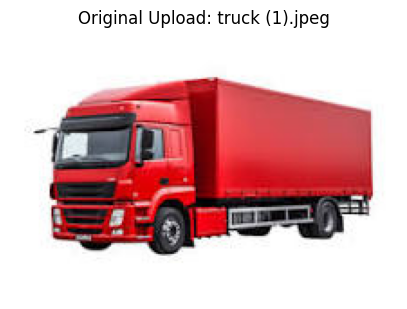

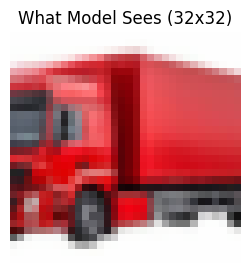

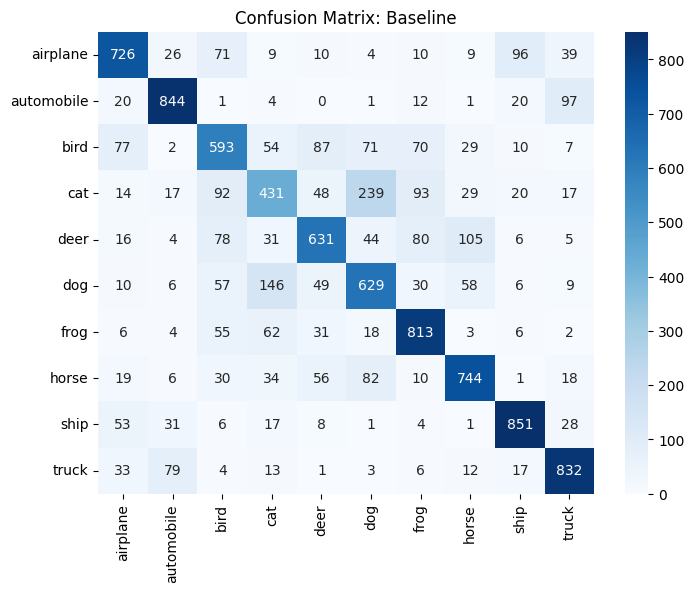

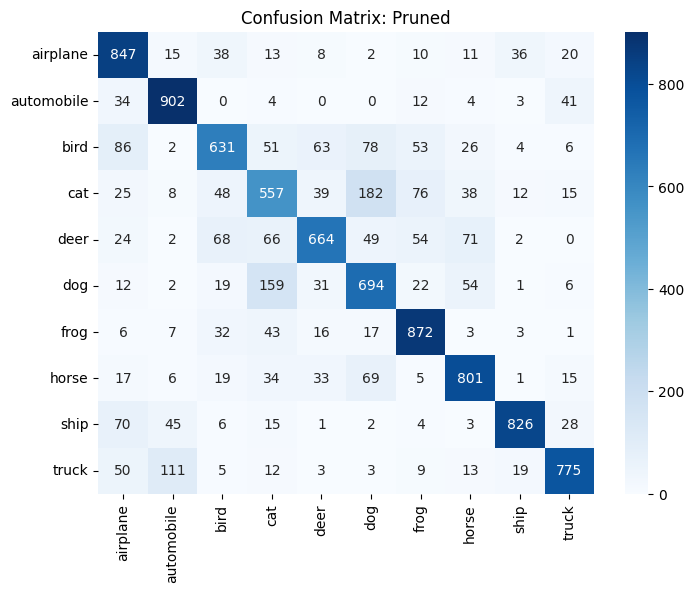

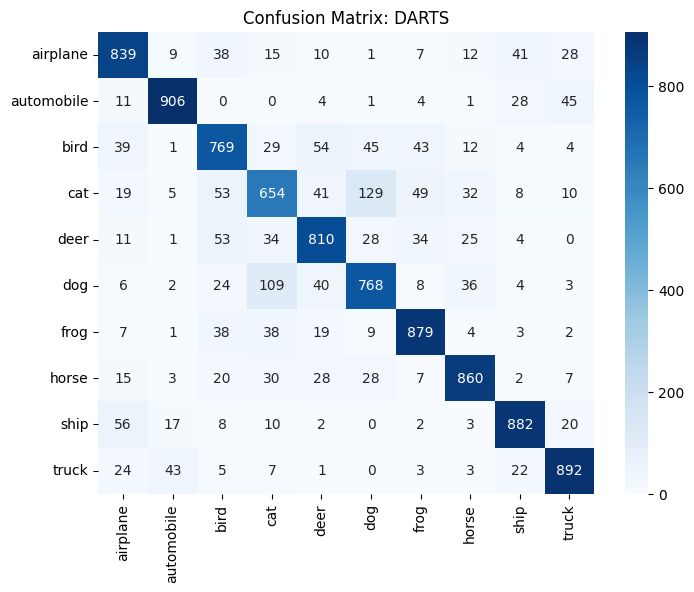

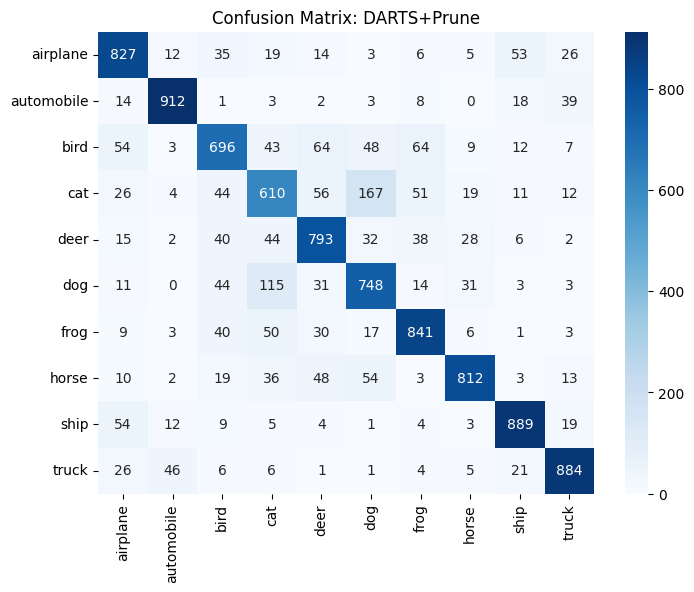

In [ ]:
import os
import copy
import time
import torch
import torch.nn as nn
from PIL import Image
from torchvision import transforms, models, datasets
from google.colab import files
import numpy as np
from sklearn.metrics import precision_score, recall_score, f1_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
CIFAR10_CLASSES = ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']

# Standard CIFAR-10 stats for Normalization
CIFAR_MEAN = (0.4914, 0.4822, 0.4465)
CIFAR_STD  = (0.2023, 0.1994, 0.2010)

# ==============================================================================
# SMART PREPROCESSING (Ensures Accuracy)
# ==============================================================================
smart_inference_transform = transforms.Compose([
    transforms.Resize(40),                # Resize smaller edge to 40 to maintain ratio
    transforms.CenterCrop(32),            # Crop a 32x32 square from the center (focus on subject)
    transforms.ToTensor(),                # Convert to tensor
    transforms.Normalize(CIFAR_MEAN, CIFAR_STD) # Match training color distribution
])

# Standard test transform for batch evaluation
test_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(CIFAR_MEAN, CIFAR_STD)
])

# ==============================================================================
# DARTS ARCHITECTURE (Required for Loading)
# ==============================================================================
class SepConv(nn.Module):
    def __init__(self, C_in, C_out, kernel_size, stride, padding, affine=True):
        super().__init__()
        self.op = nn.Sequential(
            nn.ReLU(inplace=False),
            nn.Conv2d(C_in, C_in, kernel_size, stride, padding, groups=C_in, bias=False),
            nn.Conv2d(C_in, C_in, 1, padding=0, bias=False),
            nn.BatchNorm2d(C_in, affine=affine),
            nn.ReLU(inplace=False),
            nn.Conv2d(C_in, C_in, kernel_size, 1, padding, groups=C_in, bias=False),
            nn.Conv2d(C_in, C_out, 1, padding=0, bias=False),
            nn.BatchNorm2d(C_out, affine=affine),
        )
    def forward(self, x): return self.op(x)

class PoolBN(nn.Module):
    def __init__(self, C_in, C_out, kernel_size, stride, padding):
        super().__init__()
        self.op = nn.Sequential(
            nn.MaxPool2d(kernel_size, stride=stride, padding=padding),
            nn.Conv2d(C_in, C_out, 1, bias=False),
            nn.BatchNorm2d(C_out)
        )
    def forward(self, x): return self.op(x)

def get_ops(C_in, C_out, stride):
    return {
        'sep_3x3': SepConv(C_in, C_out, 3, stride, 1),
        'sep_5x5': SepConv(C_in, C_out, 5, stride, 2),
        'max_pool': PoolBN(C_in, C_out, 3, stride, 1),
        'identity': nn.Identity(),
    }

class DARTSFinalNetwork(nn.Module):
    def __init__(self, genotype, init_channels=16, num_classes=10):
        super().__init__()
        self.genotype = genotype
        self.stem = nn.Sequential(
            nn.Conv2d(3, init_channels, 3, padding=1, bias=False),
            nn.BatchNorm2d(init_channels),
            nn.ReLU(inplace=True)
        )
        layers = []
        C_curr = init_channels
        for i, op_name in enumerate(genotype):
            stride = 2 if i in [len(genotype)//3, 2*len(genotype)//3] else 1
            C_out = C_curr if stride == 1 else C_curr * 2
            layers.append(get_ops(C_curr, C_out, stride)[op_name])
            C_curr = C_out
        self.layers = nn.Sequential(*layers)
        self.global_pooling = nn.AdaptiveAvgPool2d(1)
        self.classifier = nn.Linear(C_curr, num_classes)

    def forward(self, x):
        x = self.stem(x); x = self.layers(x)
        x = self.global_pooling(x); x = x.view(x.size(0), -1)
        return self.classifier(x)

# ==============================================================================
# RECONSTRUCTION ENGINE
# ==============================================================================
def set_module_by_path(model, path, new_module):
    parts = path.split('.')
    parent = model
    for part in parts[:-1]:
        parent = parent[int(part)] if part.isdigit() else getattr(parent, part)
    final_part = parts[-1]
    if final_part.isdigit(): parent[int(final_part)] = new_module
    else: setattr(parent, final_part, new_module)

def force_rebuild_sequential(base_model, state_dict):
    replacements = {}
    prev_out_channels = 3
    for name, module in base_model.named_modules():
        w_key = f"{name}.weight"
        if w_key in state_dict:
            ckpt_w = state_dict[w_key]
            if isinstance(module, nn.Conv2d):
                new_out = ckpt_w.shape[0]
                k_h = ckpt_w.shape[2] if len(ckpt_w.shape) == 4 else module.kernel_size[0]
                k_w = ckpt_w.shape[3] if len(ckpt_w.shape) == 4 else module.kernel_size[1]
                is_dw = (ckpt_w.shape[1] == 1 and new_out > 1 and k_h > 1)
                new_in = new_out if is_dw else prev_out_channels
                if "stem.0" in name: new_in = 3
                replacements[name] = nn.Conv2d(new_in, new_out, (k_h, k_w), module.stride, module.padding, module.dilation, groups=new_in if is_dw else 1, bias=module.bias is not None)
                prev_out_channels = new_out
            elif isinstance(module, nn.BatchNorm2d): replacements[name] = nn.BatchNorm2d(ckpt_w.shape[0])
            elif isinstance(module, nn.Linear): replacements[name] = nn.Linear(prev_out_channels, ckpt_w.shape[0])
    for path, mod in replacements.items(): set_module_by_path(base_model, path, mod)
    base_model.load_state_dict(state_dict, strict=False)
    return base_model

def safe_load_model(path, num_classes=10):
    if not os.path.exists(path): return None
    ckpt = torch.load(path, map_location='cpu')
    sd = ckpt['state_dict'] if (isinstance(ckpt, dict) and 'state_dict' in ckpt) else ckpt
    if any("stem" in k for k in sd.keys()):
        genotype = ['sep_3x3', 'max_pool', 'max_pool', 'max_pool', 'sep_5x5', 'sep_5x5']
        base = DARTSFinalNetwork(genotype, 16, num_classes)
    else: base = models.mobilenet_v2(num_classes=num_classes)
    return force_rebuild_sequential(base, sd).to(DEVICE)

# ==============================================================================
# EVALUATION & VISUALIZATION
# ==============================================================================
def plot_full_report(all_metrics, img_orig, img_tensor, img_name):
    # 1. Display Input
    plt.figure(figsize=(5, 5))
    plt.imshow(img_orig)
    plt.title(f"Original Upload: {img_name}")
    plt.axis('off'); plt.show()

    # 2. Display Model View
    plt.figure(figsize=(3, 3))
    view_img = img_tensor.squeeze().cpu().permute(1, 2, 0).numpy()
    view_img = np.clip(view_img * CIFAR_STD + CIFAR_MEAN, 0, 1)
    plt.imshow(view_img)
    plt.title("What Model Sees (32x32)")
    plt.axis('off'); plt.show()

    # 3. Confusion Matrices
    for name, metrics in all_metrics.items():
        plt.figure(figsize=(8, 6))
        sns.heatmap(metrics['cm'], annot=True, fmt='d', cmap='Blues', xticklabels=CIFAR10_CLASSES, yticklabels=CIFAR10_CLASSES)
        plt.title(f"Confusion Matrix: {name}")
        plt.show()

# ==============================================================================
# MAIN EXECUTION
# ==============================================================================
if __name__ == "__main__":
    testloader = torch.utils.data.DataLoader(datasets.CIFAR10("./data", train=False, download=True, transform=test_transform), batch_size=128)

    model_paths = {
        "Baseline": "models/baseline_mobilenetv2.pth",
        "Pruned": "models/pruned_mobilenetv2_finetuned.pth",
        "DARTS": "models/darts_final_network.pth",
        "DARTS+Prune": "models/darts_pruned_finetuned.pth"
    }

    print("📤 UPLOAD IMAGE")
    uploaded = files.upload()
    if uploaded:
        img_name = list(uploaded.keys())[0]
        img_orig = Image.open(img_name).convert('RGB')
        img_tensor = smart_inference_transform(img_orig).unsqueeze(0).to(DEVICE)

        all_results = {}
        print("\n" + "="*85)
        print(f"{'Model':<15} | {'Prediction':<12} | {'Conf (%)':<10} | {'Acc (%)':<8} | {'F1 (%)':<8}")
        print("-" * 85)

        for name, path in model_paths.items():
            model = safe_load_model(path)
            if model:
                model.eval()
                # Single Pred
                output = model(img_tensor)
                prob = torch.nn.functional.softmax(output, dim=1)
                conf, pred = torch.max(prob, 1)

                # Full Eval for metrics
                preds_list, labels_list = [], []
                with torch.no_grad():
                    for imgs, labels in testloader:
                        out = model(imgs.to(DEVICE))
                        preds_list.extend(out.argmax(1).cpu().numpy())
                        labels_list.extend(labels.numpy())

                acc = (np.array(preds_list) == np.array(labels_list)).mean() * 100
                f1 = f1_score(labels_list, preds_list, average='weighted') * 100
                cm = confusion_matrix(labels_list, preds_list)

                all_results[name] = {'cm': cm}
                print(f"{name:<15} | {CIFAR10_CLASSES[pred.item()]:<12} | {conf.item()*100:<10.2f} | {acc:<8.2f} | {f1:<8.2f}")

        plot_full_report(all_results, img_orig, img_tensor, img_name)